# 论文完整训练流程：墙体分割 + 门窗检测
## Automatic Reconstruction of Semantic 3D Models from 2D Floor Plans (MVA 2023)

### 论文架构说明

```
共享 ResNet50 Backbone
         │
    ┌────┴────┐
    │         │
  FPN头      RPN头
(墙体分割)  (门窗检测)
    │         │
 binary    bboxes
wall mask  doors/windows
```

### 论文关键设计（逐条对应）
```
Section 2.1: 滑动窗口处理不同尺寸图片
             random scaling + random rotation 数据增强

Section 2.2: 门窗检测 → Faster R-CNN + ResNet backbone
             只检测 door 和 window

Section 2.3: 墙体分割 → FPN + ResNet backbone
             BCE Loss + Affinity Field Loss
             Kendall 不确定性自动加权两个 loss

Section 3:   预处理 → 裁剪图片到 GT wall mask 的 bounding box
             去掉没有标注的边缘区域（提升数据集质量）

评估指标: IoU mask = 0.81, IoU vect = 0.80
```

### 本文件训练策略
```
两个任务共享 ResNet50 backbone
联合训练：每个 batch 同时更新 seg head 和 det head
Kendall 加权：自动平衡 BCE loss 和 Affinity loss
检测 loss 独立计算（Faster R-CNN 自带多任务 loss）
```

## 0. 环境配置

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os, sys, gc, random, logging, time, json, subprocess
from pathlib import Path
from dataclasses import dataclass, field
from typing import List, Tuple, Dict, Optional
from collections import OrderedDict

import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import resnet50, ResNet50_Weights
from torchvision.ops import FeaturePyramidNetwork
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.rpn import AnchorGenerator
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from numpy import genfromtxt
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import mlflow
from google.cloud import storage as gcs_storage
from concurrent.futures import ThreadPoolExecutor, as_completed
import hashlib, io
from PIL import Image

# ── 路径配置（自动判断环境）──
if os.path.exists('/workspace/production_3d'):
    CUBICASA_ROOT  = '/workspace/CubiCasa5k'
    DATA_FOLDER    = '/workspace/data/cubicasa5k/'
    CHECKPOINT_DIR = '/workspace/production_3d/checkpoints_paper'
    MLFLOW_DIR     = '/workspace/production_3d/mlruns'
elif os.path.exists('/content/CubiCasa5k'):
    CUBICASA_ROOT  = '/content/CubiCasa5k'
    DATA_FOLDER    = '/content/data/cubicasa5k/'
    CHECKPOINT_DIR = '/content/checkpoints_paper'
    MLFLOW_DIR     = '/content/mlruns'
else:
    CUBICASA_ROOT  = r'E:\JOB\CubiCasa5k'
    DATA_FOLDER    = r'C:/Users/kawayi_yaling/.cache/kagglehub/datasets/qmarva/cubicasa5k/versions/4/cubicasa5k/cubicasa5k/'
    CHECKPOINT_DIR = './checkpoints_paper'
    MLFLOW_DIR     = './mlruns'

os.chdir(CUBICASA_ROOT)
sys.path.insert(0, CUBICASA_ROOT)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

from floortrans.loaders.house import House

logging.basicConfig(level=logging.ERROR)
%matplotlib inline

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# ── CPU/GPU 解耦：预处理后数据存储路径 ──
GCS_BUCKET          = 'yalingdata'
GCS_PREPROCESSED    = 'preprocessed/cubicasa5k'   # GCS 上的预处理数据根目录
LOCAL_CACHE_DIR     = '/tmp/floorplan_cache'       # 本地缓存（避免重复下载）
os.makedirs(LOCAL_CACHE_DIR, exist_ok=True)
print('✓ 环境配置完成')
print(f'  device        : {DEVICE}')
print(f'  CUBICASA_ROOT : {CUBICASA_ROOT}')
print(f'  DATA_FOLDER   : {DATA_FOLDER}')
print(f'  CHECKPOINT_DIR: {CHECKPOINT_DIR}')
if torch.cuda.is_available():
    print(f'  GPU  : {torch.cuda.get_device_name(0)}')
    print(f'  VRAM : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

✓ 环境配置完成
  device        : cuda
  CUBICASA_ROOT : /workspace/CubiCasa5k
  DATA_FOLDER   : /workspace/data/cubicasa5k/
  CHECKPOINT_DIR: /workspace/production_3d/checkpoints_paper
  GPU  : NVIDIA RTX A6000
  VRAM : 50.9 GB


## 1. 训练配置

In [ ]:
@dataclass
class PaperConfig:
    # ── 数据 ──
    data_folder:   str = DATA_FOLDER

    # ── 数据集版本（三选一）──
    # 'hq'      : 只用 high_quality          → train_hq.txt / val_hq.txt
    # 'hq_arch' : 只用 high_quality_architectural → train_hq_arch.txt / val_hq_arch.txt
    # 'combined': 两者合集（去重合并）        → train_hq.txt + train_hq_arch.txt
    dataset_version: str = 'hq_arch'   # ← 改这一行切换版本

    # 以下字段由 dataset_version 自动推导，无需手动修改
    @property
    def train_files(self) -> list:
        return _version_files(self.dataset_version, 'train')

    @property
    def val_files(self) -> list:
        return _version_files(self.dataset_version, 'val')

    @property
    def test_files(self) -> list:
        return _version_files(self.dataset_version, 'test')

    # ── 类别定义（CubiCasa5k）──
    # 墙体分割
    wall_class_id: int = 2   # seg[0] 中墙体的 class id
    seg_num_classes: int = 2 # background=0, wall=1

    # 门窗检测（Faster R-CNN）
    # 0=background, 1=door, 2=window
    det_num_classes: int = 3
    door_class_id:   int = 2   # icons seg[1] 中门的 class id
    window_class_id: int = 1   # icons seg[1] 中窗的 class id
    min_bbox_area:   int = 100 # 最小 bbox 面积（像素），过滤噪声

    # ── 论文预处理（Section 3）──
    crop_to_wall:  bool = True  # 裁剪到 GT wall mask bounding box
    crop_padding:  int  = 10
    min_crop_size: int  = 64

    # ── 滑动窗口（Section 2.1）──
    tile_size:    int = 512
    tile_overlap: int = 64

    # ── 数据增强（Section 2.1）──
    # random scaling + random rotation
    aug_scale_range:      Tuple[float,float] = (0.5, 2.0)
    aug_rotation_degrees: List[int] = field(default_factory=lambda: [0, 90, 180, 270])
    aug_use_flip: bool = True

    # ── 归一化 ──
    norm_mean: Tuple = (0.485, 0.456, 0.406)
    norm_std:  Tuple = (0.229, 0.224, 0.225)

    # ── 模型（Section 2.2 + 2.3）──
    backbone:            str  = 'resnet50'
    pretrained_backbone: bool = True
    fpn_out_channels:    int  = 256

    # ── 训练超参数 ──
    batch_size:    int   = 4
    num_workers:   int   = 2
    max_epochs:    int   = 50
    learning_rate: float = 1e-4
    weight_decay:  float = 1e-4
    warmup_epochs: int   = 3
    use_amp:       bool  = True

    # ── 损失函数（Section 2.3）──
    use_affinity_loss:     bool  = True
    affinity_neighborhood: int   = 5
    # Kendall 自动加权 BCE + Affinity
    use_kendall_weighting: bool  = True
    # 类别权重（解决墙体像素少的问题）
    wall_class_weight:     float = 5.0

    # ── 检查点 ──
    checkpoint_dir: str = CHECKPOINT_DIR
    save_top_k:     int = 3

    # ── MLflow ──
    mlflow_experiment: str = 'floorplan_paper_method'
    mlflow_run_name:   str = f'paper_{time.strftime("%Y%m%d_%H%M%S")}'

    # ── GCS ──
    gcs_bucket:         str = 'yalingdata'
    gcs_project:      str = 'project-d3027d52-508f-4689-899'   # ← 加这行，填你的 project ID
    gcs_model_dir:      str = 'models/paper_method/v1.0'
    # CPU 预处理后的图片存储路径（GPU 训练从这里读）
    gcs_preprocessed:   str = 'preprocessed/cubicasa5k'
    # 训练时优先从 GCS 预处理数据读取，否则 fallback 到原始数据实时处理
    use_preprocessed:   bool = True

    # ── 图片类型自适应预处理 ──
    # 'auto'(自动检测) | 'cad'(高质量CAD导出)
    # 'phone'(手机拍摄) | 'scan'(旧建筑扫描) | 'bw'(黑白平面图)
    image_type:         str  = 'auto'
    preprocess_enabled: bool = True

    def validate(self):
        if not self.data_folder.startswith('gs://'):
            assert Path(self.data_folder).exists(), \
                f'数据目录不存在: {self.data_folder}'
        Path(self.checkpoint_dir).mkdir(parents=True, exist_ok=True)
        # 检查 split 文件是否存在
        missing = []
        for sp, files in [('train', self.train_files),
                           ('val',   self.val_files)]:
            for f in files:
                full = os.path.join(self.data_folder, f)
                if not os.path.exists(full):
                    missing.append(full)
        if missing:
            print('  ⚠ 以下 split 文件不存在，请先运行 Cell 9 生成:')
            for m in missing:
                print(f'    {m}')
        else:
            print('✓ 配置校验通过')


# ── 版本→文件映射（在 PaperConfig 外定义，供 @property 调用）──
def _version_files(version: str, split: str) -> list:
    """
    根据 dataset_version 和 split 返回对应的 txt 文件列表。
    文件名约定（均放在 data_folder 根目录）：
      high_quality              → {split}_hq.txt
      high_quality_architectural → {split}_hq_arch.txt
      combined（两者合集）       → [{split}_hq.txt, {split}_hq_arch.txt]
    """
    mapping = {
        'hq':       [f'{split}_hq.txt'],
        'hq_arch':  [f'{split}_hq_arch.txt'],
        'combined': [f'{split}_hq.txt', f'{split}_hq_arch.txt'],
    }
    if version not in mapping:
        raise ValueError(f'dataset_version 必须是 hq / hq_arch / combined，收到: {version}')
    return mapping[version]


CFG = PaperConfig()
CFG.validate()
print(f'dataset_version = {CFG.dataset_version}')
print(f'  train 文件: {CFG.train_files}')
print(f'  val   文件: {CFG.val_files}')
print(f'batch_size={CFG.batch_size}  epochs={CFG.max_epochs}  lr={CFG.learning_rate}')
print(f'wall_class_weight={CFG.wall_class_weight}')
print(f'crop_to_wall={CFG.crop_to_wall}  (Section 3 预处理)')
print(f'use_affinity={CFG.use_affinity_loss}  use_kendall={CFG.use_kendall_weighting}')

## 2. 数据工具函数

In [22]:
# ──────────────────────────────────────────
# 图片读取（支持 GCS 路径）
# ──────────────────────────────────────────
def read_image(path: str) -> np.ndarray:
    if path.startswith('gs://'):
        import gcsfs
        fs = gcsfs.GCSFileSystem()
        with fs.open(path, 'rb') as f:
            buf = np.frombuffer(f.read(), np.uint8)
            return cv2.imdecode(buf, cv2.IMREAD_COLOR)
    return cv2.imread(path)


def load_sample(data_folder: str, folder: str) -> dict:
    """加载图片 + SVG 标注，返回 image 和完整 seg tensor"""
    folder   = folder.strip('/')
    img_path = os.path.join(data_folder, folder, 'F1_scaled.png')
    svg_path = os.path.join(data_folder, folder, 'model.svg')

    img = read_image(img_path)
    if img is None:
        raise FileNotFoundError(f'图像不存在: {img_path}')
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    if svg_path.startswith('gs://'):
        import gcsfs, tempfile
        fs = gcsfs.GCSFileSystem()
        with tempfile.NamedTemporaryFile(suffix='.svg', delete=False) as tmp:
            with fs.open(svg_path, 'rb') as f:
                tmp.write(f.read())
            tmp_path = tmp.name
        house = House(tmp_path, h, w)
        os.unlink(tmp_path)
    else:
        house = House(svg_path, h, w)

    seg = house.get_segmentation_tensor()  # (C, H, W)

    # 确保 seg 至少有 2 个通道
    if seg.shape[0] < 2:
        pad = np.zeros((2 - seg.shape[0], h, w), dtype=seg.dtype)
        seg = np.concatenate([seg, pad], axis=0)

    return {'image': img, 'seg': seg}  # seg[0]=rooms, seg[1]=icons


# ──────────────────────────────────────────
# 论文预处理（Section 3）
# ──────────────────────────────────────────
def crop_to_wall_bbox(image: np.ndarray,
                      seg:   np.ndarray,
                      wall_class_id: int = 2,
                      padding: int = 10,
                      min_size: int = 64):
    """
    论文 Section 3：裁剪图片到 GT wall mask 的 bounding box
    同时裁剪 seg（所有通道）
    """
    h, w      = image.shape[:2]
    wall_mask = (seg[0] == wall_class_id)

    if wall_mask.sum() == 0:
        return None, None

    rows = np.where(wall_mask.any(axis=1))[0]
    cols = np.where(wall_mask.any(axis=0))[0]

    y1 = max(rows[0]  - padding, 0)
    y2 = min(rows[-1] + padding + 1, h)
    x1 = max(cols[0]  - padding, 0)
    x2 = min(cols[-1] + padding + 1, w)

    if (y2 - y1) < min_size or (x2 - x1) < min_size:
        return None, None

    return image[y1:y2, x1:x2], seg[:, y1:y2, x1:x2]


# ──────────────────────────────────────────
# Mask 提取
# ──────────────────────────────────────────
def extract_wall_mask(seg: np.ndarray, wall_class_id: int = 2) -> np.ndarray:
    """从 seg[0] 提取墙体二值 mask: wall=1, background=0"""
    return (seg[0] == wall_class_id).astype(np.uint8)


def extract_door_window_boxes(seg: np.ndarray,
                               door_class_id: int = 2,
                               window_class_id: int = 1,
                               min_area: int = 100
                               ) -> Tuple[np.ndarray, np.ndarray]:
    """
    从 seg[1] 提取门窗 bounding boxes
    返回: boxes (N,4) [x1,y1,x2,y2], labels (N,) 1=door 2=window
    """
    boxes, labels = [], []

    for class_id, label in [(door_class_id, 1), (window_class_id, 2)]:
        mask = (seg[1] == class_id).astype(np.uint8)
        if mask.sum() == 0:
            continue
        contours, _ = cv2.findContours(
            mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
        )
        for cnt in contours:
            area = cv2.contourArea(cnt)
            if area < min_area:
                continue
            x, y, w, h = cv2.boundingRect(cnt)
            boxes.append([x, y, x + w, y + h])
            labels.append(label)

    if boxes:
        return np.array(boxes, dtype=np.float32), np.array(labels, dtype=np.int64)
    return np.zeros((0, 4), dtype=np.float32), np.zeros((0,), dtype=np.int64)


# ──────────────────────────────────────────
# 数据增强（Section 2.1）
# ──────────────────────────────────────────
def augment_sample(image: np.ndarray,
                   seg:   np.ndarray,
                   scale_range=(0.5, 2.0),
                   rotation_degrees=[0, 90, 180, 270],
                   use_flip=True):
    """
    论文 Section 2.1: random scaling + random rotation
    同时作用于 image 和 seg（所有通道）
    """
    h, w = image.shape[:2]

    # 随机缩放
    scale   = random.uniform(*scale_range)
    new_h   = max(int(h * scale), 1)
    new_w   = max(int(w * scale), 1)
    image   = cv2.resize(image, (new_w, new_h), interpolation=cv2.INTER_LINEAR)
    new_seg = np.zeros((seg.shape[0], new_h, new_w), dtype=seg.dtype)
    for c in range(seg.shape[0]):
        new_seg[c] = cv2.resize(
            seg[c].astype(np.float32), (new_w, new_h),
            interpolation=cv2.INTER_NEAREST
        ).astype(seg.dtype)
    seg = new_seg

    # 随机旋转（90度倍数）
    angle = random.choice(rotation_degrees)
    if angle != 0:
        k     = angle // 90
        image = np.rot90(image, k).copy()
        seg   = np.rot90(seg, k, axes=(1, 2)).copy()

    # 随机水平翻转
    if use_flip and random.random() > 0.5:
        image = np.fliplr(image).copy()
        seg   = np.flip(seg, axis=2).copy()

    return image, seg


print('✓ 数据工具函数定义完成')

# ══════════════════════════════════════════════════════════════
# 图片类型自适应预处理
# ══════════════════════════════════════════════════════════════

def detect_image_type(image: np.ndarray) -> str:
    """
    自动检测图片类型
    根据图片统计特征判断来源
    """
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY).astype(np.float32) / 255.0

    # 1. 颜色通道差异：黑白图片三通道几乎相同
    ch_std = np.std([image[:,:,c].std() for c in range(3)])
    is_bw  = ch_std < 5.0

    # 2. 噪声水平：手机拍摄噪声高
    blur      = cv2.GaussianBlur(gray, (5,5), 0)
    noise_std = np.std(gray - blur)
    is_phone  = noise_std > 0.03

    # 3. 对比度：旧扫描图对比度低
    contrast   = gray.std()
    is_scan    = contrast < 0.25

    # 4. 判断顺序（优先级从高到低）
    if is_bw:    return 'bw'
    if is_scan:  return 'scan'
    if is_phone: return 'phone'
    return 'cad'


# ──────────────────────────────────────────
# 手机拍摄预处理
# 问题：噪点多、光照不均、轻微透视形变
# ──────────────────────────────────────────
def preprocess_phone(image: np.ndarray) -> np.ndarray:
    """
    手机拍摄图片预处理
    双边滤波去噪 + CLAHE 均衡 + 伽马矫正
    """
    # Step 1: 双边滤波去噪（保边）
    # d=9: 邻域直径, sigmaColor/sigmaSpace=75: 颜色/空间权重
    denoised = cv2.bilateralFilter(image, d=9,
                                    sigmaColor=75,
                                    sigmaSpace=75)

    # Step 2: CLAHE 局部直方图均衡（改善光照不均）
    # 在 LAB 空间只均衡 L 通道，不影响颜色
    lab   = cv2.cvtColor(denoised, cv2.COLOR_RGB2LAB)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    lab[:, :, 0] = clahe.apply(lab[:, :, 0])
    equalized    = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

    # Step 3: 伽马矫正（轻微提亮暗部）
    gamma   = 1.2
    table   = np.array([
        ((i / 255.0) ** (1.0 / gamma)) * 255
        for i in range(256)
    ]).astype(np.uint8)
    result  = cv2.LUT(equalized, table)

    return result


# ──────────────────────────────────────────
# 旧建筑扫描图预处理
# 问题：对比度低、纸张泛黄、斑点噪声
# ──────────────────────────────────────────
def preprocess_scan(image: np.ndarray) -> np.ndarray:
    """
    旧建筑扫描图预处理
    CLAHE 提升对比度 + 伽马矫正 + 自适应阈值去背景
    """
    # Step 1: CLAHE 提升对比度（clipLimit 更大，效果更强）
    lab   = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    lab[:, :, 0] = clahe.apply(lab[:, :, 0])
    enhanced     = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

    # Step 2: 伽马矫正（提亮暗部，让墙线更清晰）
    gamma = 1.5
    table = np.array([
        ((i / 255.0) ** (1.0 / gamma)) * 255
        for i in range(256)
    ]).astype(np.uint8)
    brightened = cv2.LUT(enhanced, table)

    # Step 3: 自适应阈值 + 背景去除
    # 把泛黄背景统一变成白色，墙线保持深色
    gray    = cv2.cvtColor(brightened, cv2.COLOR_RGB2GRAY)
    # 自适应阈值：局部区域自动计算阈值，处理不均匀背景
    binary  = cv2.adaptiveThreshold(
        gray, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        blockSize=21,   # 局部区域大小
        C=10            # 从局部均值减去的常数
    )
    # 把二值结果叠加回彩色图：背景变白，墙线保留
    bg_mask = (binary == 255)
    result  = brightened.copy()
    result[bg_mask] = 255

    return result


# ──────────────────────────────────────────
# 多张图拼接预处理
# 问题：多张照片拼接时有接缝、透视形变
# ──────────────────────────────────────────
def preprocess_stitch(images: list) -> np.ndarray:
    """
    多张图片拼接预处理
    使用 SIFT 特征匹配 + 单应变换对齐
    输入：图片列表（RGB）
    输出：拼接后的图片
    """
    if len(images) == 1:
        return images[0]

    # 转 BGR（OpenCV 特征匹配用 BGR）
    bgr_images = [cv2.cvtColor(img, cv2.COLOR_RGB2BGR) for img in images]

    # SIFT 特征检测器
    sift = cv2.SIFT_create(nfeatures=2000)

    # 以第一张为基准，逐张对齐拼接
    result_bgr = bgr_images[0]

    for i in range(1, len(bgr_images)):
        img_base = result_bgr
        img_next = bgr_images[i]

        # 灰度化（特征匹配只需要灰度）
        gray_base = cv2.cvtColor(img_base, cv2.COLOR_BGR2GRAY)
        gray_next = cv2.cvtColor(img_next, cv2.COLOR_BGR2GRAY)

        # 提取特征点和描述子
        kp1, des1 = sift.detectAndCompute(gray_base, None)
        kp2, des2 = sift.detectAndCompute(gray_next, None)

        if des1 is None or des2 is None or len(kp1) < 4 or len(kp2) < 4:
            continue

        # FLANN 特征匹配（比 BFMatcher 快）
        index_params  = dict(algorithm=1, trees=5)
        search_params = dict(checks=50)
        flann   = cv2.FlannBasedMatcher(index_params, search_params)
        matches = flann.knnMatch(des1, des2, k=2)

        # Lowe's ratio test 过滤误匹配
        good = [m for m, n in matches if m.distance < 0.7 * n.distance]

        if len(good) < 4:
            continue

        # 提取匹配点坐标
        src_pts = np.float32([kp1[m.queryIdx].pt for m in good]).reshape(-1,1,2)
        dst_pts = np.float32([kp2[m.trainIdx].pt for m in good]).reshape(-1,1,2)

        # 计算单应矩阵（RANSAC 去除外点）
        H, mask = cv2.findHomography(dst_pts, src_pts,
                                      cv2.RANSAC, ransacReprojThreshold=5.0)
        if H is None:
            continue

        # 透视变换（把 img_next 对齐到 img_base）
        h1, w1 = img_base.shape[:2]
        h2, w2 = img_next.shape[:2]
        warped  = cv2.warpPerspective(img_next, H, (w1 + w2, max(h1, h2)))

        # 拼接
        result_bgr = warped.copy()
        result_bgr[:h1, :w1] = img_base

    return cv2.cvtColor(result_bgr, cv2.COLOR_BGR2RGB)


# ──────────────────────────────────────────
# 黑白平面图预处理
# 问题：无颜色信息，线条可能粗细不均
# ──────────────────────────────────────────
def preprocess_bw(image: np.ndarray) -> np.ndarray:
    """
    黑白平面图预处理
    灰度化 + Otsu 阈值二值化 + 形态学清理
    + 转回 RGB（模型需要三通道输入）
    """
    # Step 1: 灰度化
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

    # Step 2: 高斯去噪
    blur = cv2.GaussianBlur(gray, (3, 3), 0)

    # Step 3: Otsu 自动阈值（自动找最优分割点）
    # 黑白图像双峰分布，Otsu 效果最好
    _, binary = cv2.threshold(
        blur, 0, 255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    # Step 4: 形态学清理（去除扫描斑点）
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (2, 2))
    cleaned = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)

    # Step 5: 转回 RGB（三通道，模型输入要求）
    result = cv2.cvtColor(cleaned, cv2.COLOR_GRAY2RGB)

    return result


# ──────────────────────────────────────────
# 统一入口：自适应预处理
# ──────────────────────────────────────────
def adaptive_preprocess(image:      np.ndarray,
                         image_type: str = 'auto') -> np.ndarray:
    """
    自适应预处理统一入口
    image_type: 'auto' | 'cad' | 'phone' | 'scan' | 'bw'
    """
    if image_type == 'auto':
        image_type = detect_image_type(image)

    if image_type == 'cad':
        # 高质量 CAD 图，不做额外处理
        return image
    elif image_type == 'phone':
        return preprocess_phone(image)
    elif image_type == 'scan':
        return preprocess_scan(image)
    elif image_type == 'bw':
        return preprocess_bw(image)
    else:
        return image


print('✓ 自适应预处理函数定义完成')
print('  支持类型: auto | cad | phone | scan | stitch | bw')
print('  phone : 双边滤波去噪 + CLAHE + 伽马矫正')
print('  scan  : CLAHE + 伽马矫正 + 自适应阈值去背景')
print('  stitch: SIFT特征匹配 + 单应变换 + 透视矫正')
print('  bw    : 灰度化 + Otsu阈值 + 形态学清理')

# ──────────────────────────────────────────
# GPU 训练时从 GCS 读取预处理图片
# ──────────────────────────────────────────
def _load_preprocessed_from_gcs(
        folder:     str,
        gcs_bucket: str,
        gcs_prefix: str,
) -> Optional[np.ndarray]:
    """
    从 GCS 下载预处理后的图片
    本地缓存避免重复下载（训练时反复访问同一样本）
    返回 RGB ndarray，GCS 上不存在时返回 None
    """
    folder    = folder.strip('/')
    blob_name = f'{gcs_prefix}/{folder}/F1_preprocessed.png'

    # 本地缓存路径（用 blob_name 的 hash 作为文件名）
    cache_key  = hashlib.md5(blob_name.encode()).hexdigest()
    cache_path = os.path.join(LOCAL_CACHE_DIR, f'{cache_key}.png')

    # 命中缓存直接读取
    if os.path.exists(cache_path):
        img = cv2.imread(cache_path)
        if img is not None:
            return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # 从 GCS 下载
    try:
        client    = gcs_storage.Client()
        bucket    = client.bucket(gcs_bucket)
        blob      = bucket.blob(blob_name)
        if not blob.exists():
            return None
        img_bytes = blob.download_as_bytes()
        img_array = np.array(Image.open(io.BytesIO(img_bytes)))
        # 写入本地缓存
        cv2.imwrite(cache_path,
                    cv2.cvtColor(img_array, cv2.COLOR_RGB2BGR))
        return img_array
    except Exception:
        return None


✓ 数据工具函数定义完成
✓ 自适应预处理函数定义完成
  支持类型: auto | cad | phone | scan | stitch | bw
  phone : 双边滤波去噪 + CLAHE + 伽马矫正
  scan  : CLAHE + 伽马矫正 + 自适应阈值去背景
  stitch: SIFT特征匹配 + 单应变换 + 透视矫正
  bw    : 灰度化 + Otsu阈值 + 形态学清理


## 3. 数据集

## 2.5 CPU 端批量预处理（解耦 CPU/GPU）

```
职责划分：
  CPU 环境（本地/廉价实例）：批量预处理 → 上传 GCS
  GPU 环境（Vast.ai）       ：直接从 GCS 读取已处理数据 → 训练

优点：
  GPU 机器不做 IO 密集的预处理，显存和算力全部用于训练
  预处理结果可复用，多次训练不重复计算
  RUN_PREPROCESSING=False 时此 cell 无副作用
```

In [6]:
# ══════════════════════════════════════════════════════════════
# CPU 端批量预处理 + 上传 GCS
# 职责分离：预处理在 CPU 机器上离线完成
#           GPU 机器直接读取已处理好的数据训练
#
# 运行时机：训练前在 CPU 环境运行一次
# 运行环境：不需要 GPU，Vast.ai CPU 实例或本地机器均可
# ══════════════════════════════════════════════════════════════

def _encode_image(image_rgb: np.ndarray, quality: int = 95) -> bytes:
    """把 RGB ndarray 编码成 PNG bytes"""
    pil_img = Image.fromarray(image_rgb.astype(np.uint8))
    buf = io.BytesIO()
    pil_img.save(buf, format='PNG', optimize=False)
    return buf.getvalue()


def _gcs_exists(bucket, blob_name: str) -> bool:
    """检查 GCS 上的文件是否已存在"""
    return bucket.blob(blob_name).exists()


import contextlib, os
from tqdm.notebook import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed


def _suppress_stderr():
    """临时抑制 C 库的 stderr（libpng warning 来自 C 层，只能用 os.dup2 拦截）"""
    devnull    = os.open(os.devnull, os.O_WRONLY)
    old_stderr = os.dup(2)
    os.dup2(devnull, 2)
    os.close(devnull)
    return old_stderr

def _restore_stderr(old_stderr):
    os.dup2(old_stderr, 2)
    os.close(old_stderr)

def _is_valid_preprocessed(out_img: str, min_size_kb: float = 5.0) -> bool:
    """文件存在且大小超过阈值才认为有效（排除空文件/损坏文件）"""
    if not os.path.exists(out_img):
        return False
    return os.path.getsize(out_img) > min_size_kb * 1024

def batch_preprocess_local(
        data_folder:  str,
        split_files:  List[str],
        output_dir:   str,
        image_type:   str  = 'auto',
        overwrite:    bool = False,
        max_workers:  int  = 8,
) -> dict:

    # ── 收集所有 folder ──
    all_folders = []
    for split_file in split_files:
        path = os.path.join(data_folder, split_file)
        if not os.path.exists(path):
            print(f'  split 文件不存在: {path}')
            continue
        folders = genfromtxt(path, dtype='str').tolist()
        if isinstance(folders, str):
            folders = [folders]
        all_folders.extend(folders)

    print(f'共 {len(all_folders)} 个样本，输出目录: {output_dir}')
    os.makedirs(output_dir, exist_ok=True)

    # ── 单样本处理函数 ──
    def process_one(folder):
        folder   = folder.strip('/')
        out_img  = os.path.join(output_dir, folder, 'F1_preprocessed.png')
        out_meta = os.path.join(output_dir, folder, 'meta.json')

        if not overwrite and _is_valid_preprocessed(out_img):
            return {'folder': folder, 'status': 'skipped'}

        try:
            # 读图，抑制 libpng iCCP warning
            old_stderr = _suppress_stderr()
            img_bgr    = cv2.imread(os.path.join(data_folder, folder, 'F1_scaled.png'))
            _restore_stderr(old_stderr)

            if img_bgr is None:
                return {'folder': folder, 'status': 'error', 'reason': 'image not found'}

            img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

            detected_type = detect_image_type(img_rgb) if image_type == 'auto' else image_type
            img_processed = adaptive_preprocess(img_rgb, detected_type)

            os.makedirs(os.path.dirname(out_img), exist_ok=True)

            # 保存时也抑制，同时去掉 ICC profile
            old_stderr = _suppress_stderr()
            cv2.imwrite(
                out_img,
                cv2.cvtColor(img_processed, cv2.COLOR_RGB2BGR),
                [cv2.IMWRITE_PNG_COMPRESSION, 1],  # 1=快速压缩
            )
            _restore_stderr(old_stderr)

            with open(out_meta, 'w') as f:
                json.dump({
                    'folder':          folder,
                    'image_type':      detected_type,
                    'original_shape':  list(img_rgb.shape),
                    'processed_shape': list(img_processed.shape),
                    'timestamp':       time.strftime('%Y-%m-%dT%H:%M:%SZ'),
                }, f)

            return {'folder': folder, 'status': 'done', 'image_type': detected_type}

        except Exception as e:
            return {'folder': folder, 'status': 'error', 'reason': str(e)}

    # ── 并行执行 + tqdm 进度条 ──
    stats        = {'done': 0, 'skipped': 0, 'error': 0}
    type_counter = {}
    t0           = time.time()

    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        futures = {ex.submit(process_one, f): f for f in all_folders}

        with tqdm(total=len(all_folders), desc='预处理进度',
                  unit='张', dynamic_ncols=True) as pbar:
            for future in as_completed(futures):
                r      = future.result()
                status = r['status']
                stats[status] = stats.get(status, 0) + 1

                if status == 'done':
                    t = r.get('image_type', 'unknown')
                    type_counter[t] = type_counter.get(t, 0) + 1
                elif status == 'error':
                    tqdm.write(f'ERROR {r["folder"]}: {r.get("reason")}')

                pbar.set_postfix({
                    'done': stats['done'],
                    'skip': stats['skipped'],
                    'err':  stats['error'],
                    'type': max(type_counter, key=type_counter.get) if type_counter else '-',
                }, refresh=False)
                pbar.update(1)

    elapsed = time.time() - t0
    print(f'\n完成  耗时={elapsed:.0f}s ({elapsed/60:.1f}min)')
    print(f'  done={stats["done"]}  skipped={stats["skipped"]}  error={stats["error"]}')
    print(f'  图片类型分布: {type_counter}')
    return stats


# ══════════════════════════════════════════════════════════════
# 生成子集 split 文件（首次使用时运行一次）
# ══════════════════════════════════════════════════════════════

def generate_hq_split_files(data_folder: str, overwrite: bool = False):
    """
    扫描 data_folder 下的子文件夹，生成三个版本的 split 文件：
      {split}_hq.txt      : high_quality 子集
      {split}_hq_arch.txt : high_quality_architectural 子集
    combined 版本不单独生成文件，由 FloorplanDataset 同时加载以上两个文件实现。

    文件格式与原始 train.txt 完全一致（每行一个相对路径）。
    """
    SUBFOLDER_MAP = {
        'high_quality':               'hq',
        'high_quality_architectural': 'hq_arch',
    }
    generated = []

    for split in ('train', 'val', 'test'):
        src_file = os.path.join(data_folder, f'{split}.txt')
        if not os.path.exists(src_file):
            print(f'  [skip] {src_file} 不存在，跳过')
            continue

        all_folders = genfromtxt(src_file, dtype='str').tolist()
        if isinstance(all_folders, str):
            all_folders = [all_folders]

        # 按子文件夹分桶
        buckets = {tag: [] for tag in SUBFOLDER_MAP.values()}
        unmatched = 0
        for folder in all_folders:
            parts = folder.strip('/').split('/')
            subfolder = parts[0] if parts else ''
            tag = SUBFOLDER_MAP.get(subfolder)
            if tag:
                buckets[tag].append(folder)
            else:
                unmatched += 1

        if unmatched > 0:
            print(f'  [info] {split}: {unmatched} 个 folder 不属于 hq/hq_arch，已忽略')

        # 写出各子集文件
        for tag, folders in buckets.items():
            out_path = os.path.join(data_folder, f'{split}_{tag}.txt')
            if os.path.exists(out_path) and not overwrite:
                print(f'  [skip]  {os.path.basename(out_path)} 已存在（overwrite=False）')
                continue
            with open(out_path, 'w') as f:
                f.write('\n'.join(folders) + ('\n' if folders else ''))
            generated.append(out_path)
            print(f'  [done]  {os.path.basename(out_path):30s} {len(folders)} 个样本')

    return generated


# ── Step A: 生成 split 文件（首次运行改为 True）──
RUN_GENERATE_SPLITS = False

if RUN_GENERATE_SPLITS:
    print(f'扫描: {CFG.data_folder}')
    gen = generate_hq_split_files(CFG.data_folder, overwrite=False)
    print(f'\n共生成 {len(gen)} 个 split 文件')
    # 验证三个版本的样本数
    print('\n三个版本样本数统计：')
    for version in ('hq', 'hq_arch', 'combined'):
        for split in ('train', 'val'):
            files = _version_files(version, split)
            total = 0
            for f in files:
                fpath = os.path.join(CFG.data_folder, f)
                if os.path.exists(fpath):
                    rows = genfromtxt(fpath, dtype='str')
                    total += len(rows) if rows.ndim > 0 else 1
            print(f'  {version:10s} {split:5s}: {total} 个样本  {files}')
else:
    print('跳过 split 文件生成（RUN_GENERATE_SPLITS=False）')
    print('首次使用时将 RUN_GENERATE_SPLITS 改为 True')


# ══════════════════════════════════════════════════════════════
# ── Step B: 批量预处理（生成 split 文件后运行）──
# ══════════════════════════════════════════════════════════════

LOCAL_PREPROCESS_DIR = '/workspace/preprocessed_cubicasa'
RUN_PREPROCESSING    = False   # ← 改为 True 开始处理

if RUN_PREPROCESSING:
    # 三个版本共用同一份预处理图片（图片内容相同，只是 split 不同）
    # 因此只需要把所有涉及的 split 文件合并后预处理一次
    all_split_files = list(dict.fromkeys(
        _version_files('hq',      'train') + _version_files('hq',      'val') +
        _version_files('hq_arch', 'train') + _version_files('hq_arch', 'val')
    ))
    print(f'将预处理以下 split 文件中的图片: {all_split_files}')
    stats = batch_preprocess_local(
        data_folder = CFG.data_folder,
        split_files = all_split_files,
        output_dir  = LOCAL_PREPROCESS_DIR,
        image_type  = 'auto',
        overwrite   = False,
        max_workers = 8,
    )
    print(f'\n处理完成，运行下方 Cell 上传到 GCS')
else:
    print('跳过预处理（RUN_PREPROCESSING=False）')


跳过 split 文件生成（RUN_GENERATE_SPLITS=False）
首次使用时将 RUN_GENERATE_SPLITS 改为 True
将预处理以下 split 文件中的图片: ['train_hq.txt', 'val_hq.txt', 'train_hq_arch.txt', 'val_hq_arch.txt']
共 4250 个样本，输出目录: /workspace/preprocessed_cubicasa


预处理进度:   0%|          | 0/4250 [00:00<?, ?张/s]


完成  耗时=69s (1.2min)
  done=4250  skipped=0  error=0
  图片类型分布: {'bw': 3923, 'phone': 36, 'scan': 291}

处理完成，运行下方 Cell 上传到 GCS


In [7]:
import json
from pathlib import Path
from collections import Counter

out_dir    = '/workspace/preprocessed_cubicasa'
meta_files = list(Path(out_dir).rglob('meta.json'))

type_counter = Counter()
for meta_path in meta_files:
    try:
        with open(meta_path) as f:
            meta = json.load(f)
        type_counter[meta.get('image_type', 'unknown')] += 1
    except Exception:
        type_counter['parse_error'] += 1

print(f'统计了 {len(meta_files)} 个 meta 文件')
print('图片类型分布:')
for t, count in type_counter.most_common():
    pct = count / len(meta_files) * 100
    print(f'  {t:<10} {count:>5} 张  ({pct:.1f}%)')

统计了 4250 个 meta 文件
图片类型分布:
  bw          3923 张  (92.3%)
  scan         291 张  (6.8%)
  phone         36 张  (0.8%)


In [8]:
# ── 上传到 GCS（预处理完成后单独运行这个 Cell）──
RUN_GCS_UPLOAD = True   # ← 确认本地处理无误后改为 True

if RUN_GCS_UPLOAD:
    GSUTIL = '/root/google-cloud-sdk/bin/gsutil'   # ← 换成你找到的路径
    GCS_DEST = f'gs://{CFG.gcs_bucket}/{CFG.gcs_preprocessed}/'
    
    print(f'开始上传: {LOCAL_PREPROCESS_DIR} → {GCS_DEST}')
    cmd = f'{GSUTIL} -m cp -r -n {LOCAL_PREPROCESS_DIR}/* {GCS_DEST}'
    print(f'执行命令: {cmd}')
    
    ret = subprocess.run(cmd, shell=True, text=True,
                         env={**os.environ, 'PATH': f'/root/google-cloud-sdk/bin:{os.environ["PATH"]}'})
    if ret.returncode == 0:
        print('✓ 上传完成')
    else:
        print('✗ 上传失败')

开始上传: /workspace/preprocessed_cubicasa → gs://yalingdata/preprocessed/cubicasa5k/
执行命令: /root/google-cloud-sdk/bin/gsutil -m cp -r -n /workspace/preprocessed_cubicasa/* gs://yalingdata/preprocessed/cubicasa5k/
✓ 上传完成


In [9]:
import subprocess
ret = subprocess.run('find / -name "gsutil" 2>/dev/null | head -5', 
                     shell=True, capture_output=True, text=True)
print(ret.stdout)



/root/google-cloud-sdk/bin/gsutil
/root/google-cloud-sdk/platform/gsutil
/root/google-cloud-sdk/platform/gsutil/gsutil
/venv/main/bin/gsutil



## 2.6 预处理结果验证

验证内容：GCS 文件完整性 / 图片质量 / 类型分布 / 视觉对比

验证 1：GCS 文件完整性
  ✓ 上传率: 99/99 = 100.0%

验证 2-4：图片质量（抽查 20 个样本）
  ✓ 尺寸/通道正确 : 20/20
  ✓ 亮度范围合理  : 20/20  (5 < mean < 250)
  ✓ 对比度足够    : 20/20   (std > 10)

验证 5：图片类型分布
  bw        : ████████████████ (16)
  scan      : ███ (3)
  phone     : █ (1)

验证 6：各样本详细指标
  folder                    type     shape             bright  contrast  ok?
  -------------------------------------------------------------------------
  high_quality/12687        bw       (1008, 726, 3)     222.1      85.5    ✓
  high_quality/12695        bw       (1117, 1113, 3)    234.6      69.2    ✓
  high_quality/11131        bw       (1277, 2195, 3)    221.5      86.1    ✓
  high_quality/5668         bw       (658, 992, 3)      237.1      65.2    ✓
  high_quality/1885         bw       (1137, 1399, 3)    227.6      78.9    ✓
  high_quality/3707         bw       (1094, 848, 3)     221.7      86.0    ✓
  high_quality/6367         phone    (715, 635, 3)      226.0      67.7    ✓
  high_quality/9002         bw       (1437, 764,

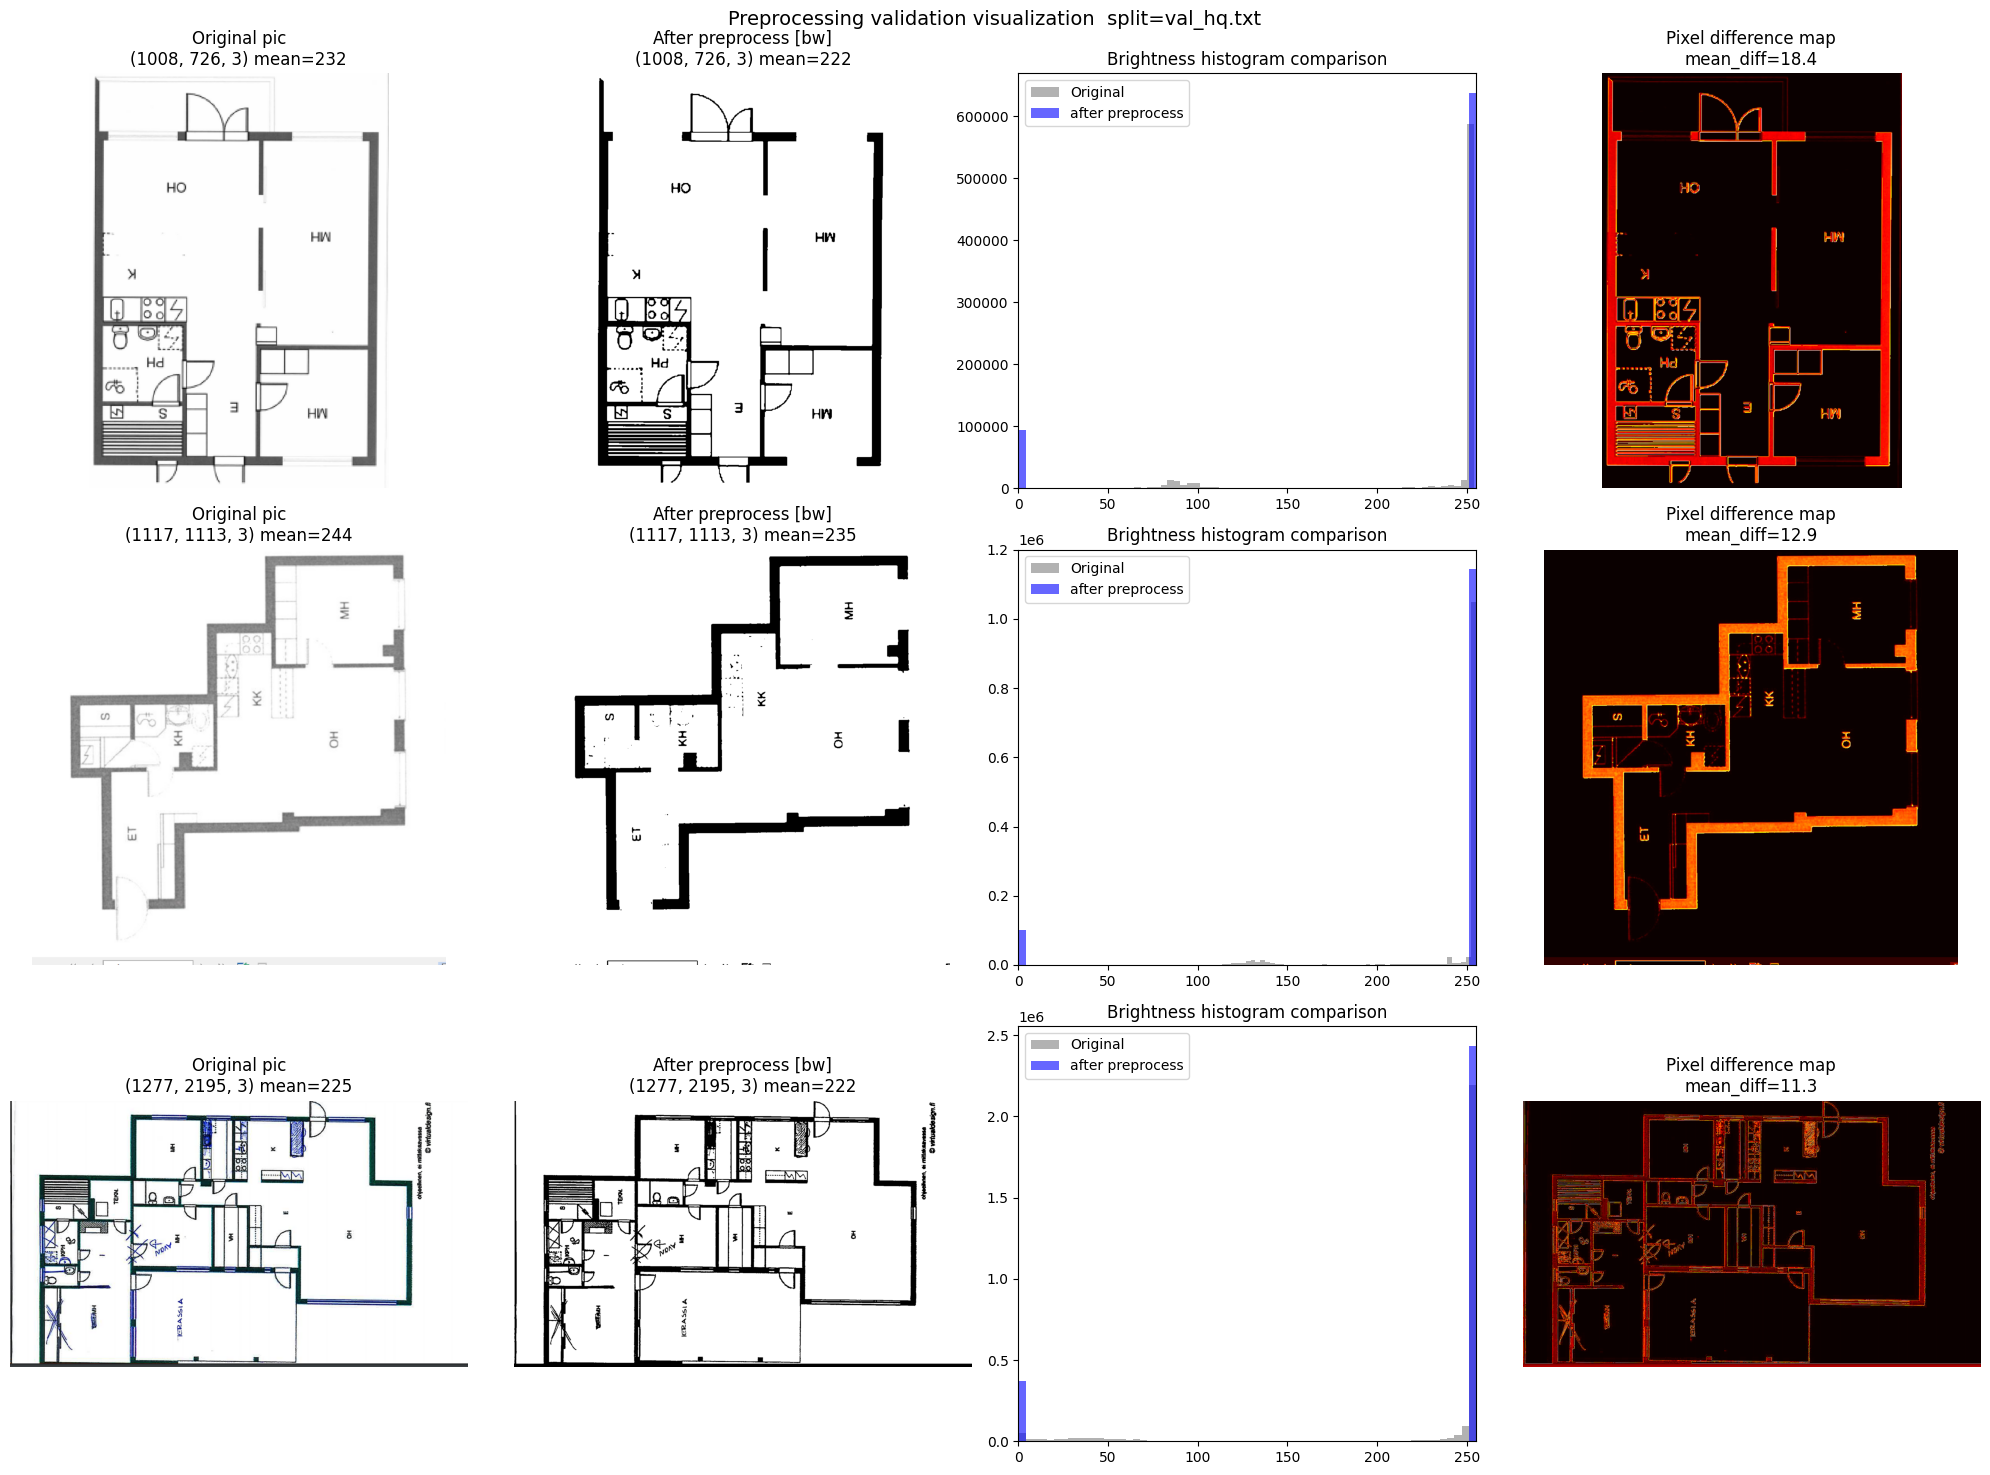

  Verification image has been saved: /workspace/production_3d/checkpoints_paper/preprocess_validation.png

验证报告摘要:
  upload_rate: 1.0000
  shape_ok_rate: 1.0000
  brightness_ok: 1.0000
  contrast_ok: 1.0000


In [12]:
# ══════════════════════════════════════════════════════════════
# 预处理验证：对比原始图片和预处理后的图片
# 验证内容：
#   1. GCS 文件完整性（是否全部上传）
#   2. 图片尺寸和通道数一致性
#   3. 像素值分布合理性（亮度/对比度）
#   4. 原始 vs 预处理的视觉对比
# ══════════════════════════════════════════════════════════════

def verify_preprocessing(
        data_folder:  str,
        gcs_bucket:   str,
        gcs_project:  str,
        gcs_prefix:   str,
        split_file:   str = 'val.txt',
        n_check:      int = 5,
        n_visual:     int = 3,
) -> dict:
    """
    验证 GCS 上的预处理结果

    验证指标：
      upload_rate    : GCS 上文件存在率
      shape_ok_rate  : 尺寸格式正确率
      brightness_ok  : 亮度范围是否合理（5-250，排除全黑/全白）
      contrast_ok    : 对比度是否足够（std > 10）
      type_dist      : 各图片类型的分布
    """
    client = client = gcs_storage.Client(project=gcs_project)
    bucket = client.bucket(gcs_bucket)

    folders = genfromtxt(
        os.path.join(data_folder, split_file), dtype='str'
    ).tolist()
    if isinstance(folders, str):
        folders = [folders]

    # 随机抽样
    import random as rnd
    check_folders  = rnd.sample(folders, min(n_check, len(folders)))
    visual_folders = rnd.sample(folders, min(n_visual, len(folders)))

    # ── 验证 1：文件完整性 ──
    print('=' * 55)
    print('验证 1：GCS 文件完整性')
    print('=' * 55)
    total       = len(folders)
    exist_count = 0
    for folder in folders:
        folder = folder.strip('/')
        blob   = f'{gcs_prefix}/{folder}/F1_preprocessed.png'
        if bucket.blob(blob).exists():
            exist_count += 1
    upload_rate = exist_count / total
    status = '✓' if upload_rate >= 0.99 else '✗'
    print(f'  {status} 上传率: {exist_count}/{total} = {upload_rate*100:.1f}%')
    print()

    # ── 验证 2-4：图片质量检查 ──
    print('=' * 55)
    print(f'验证 2-4：图片质量（抽查 {n_check} 个样本）')
    print('=' * 55)

    shape_ok    = 0
    brightness_ok = 0
    contrast_ok = 0
    type_dist   = {}
    check_results = []

    for folder in check_folders:
        folder = folder.strip('/')
        blob_name = f'{gcs_prefix}/{folder}/F1_preprocessed.png'
        meta_name = f'{gcs_prefix}/{folder}/meta.json'

        try:
            # 下载图片
            img_bytes = bucket.blob(blob_name).download_as_bytes()
            img = np.array(Image.open(io.BytesIO(img_bytes)))

            # 读取 meta
            meta_bytes = bucket.blob(meta_name).download_as_text()
            meta = json.loads(meta_bytes)
            img_type = meta.get('image_type', 'unknown')
            type_dist[img_type] = type_dist.get(img_type, 0) + 1

            # 检查尺寸
            shape_valid = (img.ndim == 3 and img.shape[2] == 3)
            if shape_valid: shape_ok += 1

            # 检查亮度（排除全黑全白）
            mean_brightness = img.mean()
            brightness_valid = 5 < mean_brightness < 250
            if brightness_valid: brightness_ok += 1

            # 检查对比度
            contrast = img.std()
            contrast_valid = contrast > 10
            if contrast_valid: contrast_ok += 1

            check_results.append({
                'folder':     folder,
                'img_type':   img_type,
                'shape':      img.shape,
                'brightness': round(float(mean_brightness), 1),
                'contrast':   round(float(contrast), 1),
                'shape_ok':   shape_valid,
                'bright_ok':  brightness_valid,
                'contrast_ok': contrast_valid,
                'img':        img,
            })

        except Exception as e:
            print(f'  ERROR {folder}: {e}')
            check_results.append({'folder': folder, 'img_type': 'error', 'img': None})

    n = len(check_results)
    s1 = '✓' if shape_ok    == n else '✗'
    s2 = '✓' if brightness_ok >= n * 0.9 else '✗'
    s3 = '✓' if contrast_ok  >= n * 0.9 else '✗'
    print(f'  {s1} 尺寸/通道正确 : {shape_ok}/{n}')
    print(f'  {s2} 亮度范围合理  : {brightness_ok}/{n}  (5 < mean < 250)')
    print(f'  {s3} 对比度足够    : {contrast_ok}/{n}   (std > 10)')
    print()

    # ── 验证 5：图片类型分布 ──
    print('=' * 55)
    print('验证 5：图片类型分布')
    print('=' * 55)
    for t, cnt in sorted(type_dist.items(), key=lambda x: -x[1]):
        bar = '█' * cnt
        print(f'  {t:10s}: {bar} ({cnt})')
    print()

    # ── 验证 6：详细指标表格 ──
    print('=' * 55)
    print('验证 6：各样本详细指标')
    print('=' * 55)
    print(f'  {"folder":<25} {"type":<8} {"shape":<16} {"bright":>7} {"contrast":>9} {"ok?":>4}')
    print('  ' + '-' * 73)
    for r in check_results:
        if r.get('img') is None: continue
        all_ok = r['shape_ok'] and r['bright_ok'] and r['contrast_ok']
        flag   = '✓' if all_ok else '✗'
        print(f'  {r["folder"]:<25} {r["img_type"]:<8} '
              f'{str(r["shape"]):<16} '
              f'{r["brightness"]:>7.1f} '
              f'{r["contrast"]:>9.1f} '
              f'{flag:>4}')
    print()

    # ── 验证 7：视觉对比（原始 vs 预处理）──
    print('=' * 55)
    print(f'验证 7：原始 vs 预处理 视觉对比')
    print('=' * 55)

    visual_results = [r for r in check_results
                      if r.get('img') is not None][:n_visual]

    if visual_results:
        fig, axes = plt.subplots(
            len(visual_results), 4,
            figsize=(20, 5 * len(visual_results))
        )
        if len(visual_results) == 1:
            axes = [axes]

        for row, r in enumerate(visual_results):
            folder = r['folder'].strip('/')

            # 原始图片
            orig_path = os.path.join(data_folder, folder, 'F1_scaled.png')
            orig_bgr  = cv2.imread(orig_path)
            if orig_bgr is None:
                continue
            orig_rgb  = cv2.cvtColor(orig_bgr, cv2.COLOR_BGR2RGB)
            proc_rgb  = r['img']

            # 原始灰度直方图
            orig_gray = cv2.cvtColor(orig_rgb, cv2.COLOR_RGB2GRAY)
            proc_gray = cv2.cvtColor(proc_rgb, cv2.COLOR_RGB2GRAY)

            axes[row][0].imshow(orig_rgb)
            axes[row][0].set_title(
                f'Original pic\n{orig_rgb.shape} '
                f'mean={orig_gray.mean():.0f}'
            )
            axes[row][0].axis('off')

            axes[row][1].imshow(proc_rgb)
            axes[row][1].set_title(
                f'After preprocess [{r["img_type"]}]\n{proc_rgb.shape} '
                f'mean={proc_gray.mean():.0f}'
            )
            axes[row][1].axis('off')

            # 亮度直方图对比
            axes[row][2].hist(
                orig_gray.ravel(), bins=64,
                color='gray', alpha=0.6, label='Original'
            )
            axes[row][2].hist(
                proc_gray.ravel(), bins=64,
                color='blue', alpha=0.6, label='after preprocess'
            )
            axes[row][2].set_title('Brightness histogram comparison')
            axes[row][2].legend()
            axes[row][2].set_xlim(0, 255)

            # 差异图
            if orig_rgb.shape == proc_rgb.shape:
                diff = np.abs(
                    orig_gray.astype(int) - proc_gray.astype(int)
                ).astype(np.uint8)
                axes[row][3].imshow(diff, cmap='hot')
                axes[row][3].set_title(
                    f'Pixel difference map\nmean_diff={diff.mean():.1f}'
                )
            else:
                axes[row][3].text(
                    0.5, 0.5, 'different sizes\n Unable to calculate difference',
                    ha='center', va='center',
                    transform=axes[row][3].transAxes
                )
            axes[row][3].axis('off')

        plt.suptitle(
            f'Preprocessing validation visualization  split={split_file}',
            fontsize=14
        )
        plt.tight_layout()
        vis_path = os.path.join(CHECKPOINT_DIR, 'preprocess_validation.png')
        plt.savefig(vis_path, dpi=100, bbox_inches='tight')
        plt.show()
        print(f'  Verification image has been saved: {vis_path}')

    return {
        'upload_rate':    upload_rate,
        'shape_ok_rate':  shape_ok / max(n, 1),
        'brightness_ok':  brightness_ok / max(n, 1),
        'contrast_ok':    contrast_ok / max(n, 1),
        'type_dist':      type_dist,
    }


# ── 执行验证 ──
RUN_VALIDATION = True   # 改为 True 开始验证

if RUN_VALIDATION:
    val_report = verify_preprocessing(
        data_folder = CFG.data_folder,
        gcs_bucket  = CFG.gcs_bucket,
        gcs_project = CFG.gcs_project,
        gcs_prefix  = CFG.gcs_preprocessed,
        split_file  = 'val_hq.txt',
        n_check     = 20,    # 随机抽查 20 个样本做指标验证
        n_visual    = 3,     # 可视化对比 3 个样本
    )
    print('\n验证报告摘要:')
    for k, v in val_report.items():
        if k != 'type_dist':
            print(f'  {k}: {v:.4f}' if isinstance(v, float) else f'  {k}: {v}')
else:
    print('跳过验证（RUN_VALIDATION=False）')
    print('如需验证预处理结果，将 RUN_VALIDATION 改为 True')


In [23]:
class FloorplanDataset(Dataset):
    """
    联合数据集：同时提供墙体分割标注和门窗检测标注
    实现论文的完整预处理流程
    """

    def __init__(self, cfg: PaperConfig, split: str = 'train'):
        self.cfg      = cfg
        self.is_train = (split == 'train')

        # ── 按 dataset_version 加载对应的一个或多个 split 文件 ──
        file_list = cfg.train_files if split == 'train' else (
                    cfg.val_files   if split == 'val'   else cfg.test_files)

        all_folders = []
        for filename in file_list:
            full_path = cfg.data_folder + filename
            if full_path.startswith('gs://'):
                import gcsfs
                fs = gcsfs.GCSFileSystem()
                with fs.open(full_path, 'r') as f:
                    rows = f.read().splitlines()
            else:
                local_path = os.path.join(cfg.data_folder, filename)
                if not os.path.exists(local_path):
                    print(f'  ⚠ split 文件不存在，跳过: {filename}')
                    continue
                rows = genfromtxt(local_path, dtype='str').tolist()
                if isinstance(rows, str):
                    rows = [rows]
            all_folders.extend(rows)

        # combined 版本两个文件可能有重叠，去重并保持顺序
        seen, unique = set(), []
        for f in all_folders:
            if f not in seen:
                seen.add(f); unique.append(f)

        self.folders = np.array(unique)
        print(f'[{split}] version={cfg.dataset_version}  '
              f'files={file_list}  →  {len(self.folders)} 个样本')

    def __len__(self):
        return len(self.folders)

    def __getitem__(self, idx: int) -> dict:
        folder = self.folders[idx]
        try:
            # 1. 加载图片和标注
            #    优先从 GCS 预处理数据读取（GPU 训练解耦 CPU 预处理）
            #    如果 GCS 上没有，fallback 到原始数据实时处理
            sample = load_sample(self.cfg.data_folder, folder)
            seg    = sample['seg']     # (C, H, W)

            if self.cfg.use_preprocessed:
                image = _load_preprocessed_from_gcs(
                    folder, self.cfg.gcs_bucket,
                    self.cfg.gcs_preprocessed
                )
                if image is None:
                    # GCS 上没有预处理图片，fallback 实时处理
                    image = sample['image']
                    if self.cfg.preprocess_enabled:
                        image = adaptive_preprocess(image, self.cfg.image_type)
            else:
                image = sample['image']
                # 2. 实时自适应预处理
                if self.cfg.preprocess_enabled:
                    image = adaptive_preprocess(image, self.cfg.image_type)

            # 3. 论文预处理：裁剪到 wall bbox（Section 3）
            if self.cfg.crop_to_wall:
                image, seg = crop_to_wall_bbox(
                    image, seg,
                    self.cfg.wall_class_id,
                    self.cfg.crop_padding,
                    self.cfg.min_crop_size,
                )
                if image is None:
                    return self._empty()

            # 4. 数据增强（仅训练集，Section 2.1）
            if self.is_train:
                image, seg = augment_sample(
                    image, seg,
                    self.cfg.aug_scale_range,
                    self.cfg.aug_rotation_degrees,
                    self.cfg.aug_use_flip,
                )

            # 5. 滑动窗口：随机取一个 tile（Section 2.1）
            h, w   = image.shape[:2]
            ts     = self.cfg.tile_size
            stride = ts - self.cfg.tile_overlap

            ys = list(range(0, max(h - ts + 1, 1), stride))
            xs = list(range(0, max(w - ts + 1, 1), stride))
            if not ys or ys[-1] + ts < h: ys.append(max(h - ts, 0))
            if not xs or xs[-1] + ts < w: xs.append(max(w - ts, 0))

            ty = random.choice(list(set(ys)))
            tx = random.choice(list(set(xs)))

            img_tile = image[ty:ty+ts, tx:tx+ts].copy()
            seg_tile = seg[:, ty:ty+ts, tx:tx+ts].copy()

            # Padding
            th, tw = img_tile.shape[:2]
            if th < ts or tw < ts:
                img_tile = cv2.copyMakeBorder(
                    img_tile, 0, ts-th, 0, ts-tw, cv2.BORDER_REFLECT_101
                )
                new_seg = np.zeros((seg_tile.shape[0], ts, ts), dtype=seg_tile.dtype)
                new_seg[:, :th, :tw] = seg_tile
                seg_tile = new_seg

            img_tile = cv2.resize(img_tile, (ts, ts), interpolation=cv2.INTER_LINEAR)
            seg_r = np.zeros((seg_tile.shape[0], ts, ts), dtype=seg_tile.dtype)
            for c in range(seg_tile.shape[0]):
                seg_r[c] = cv2.resize(
                    seg_tile[c].astype(np.float32), (ts, ts),
                    interpolation=cv2.INTER_NEAREST
                ).astype(seg_tile.dtype)
            seg_tile = seg_r

            # 6. 提取墙体 mask
            wall_mask = extract_wall_mask(seg_tile, self.cfg.wall_class_id)

            # 7. 提取门窗 bbox（Faster R-CNN 格式）
            boxes, labels = extract_door_window_boxes(
                seg_tile,
                self.cfg.door_class_id,
                self.cfg.window_class_id,
                self.cfg.min_bbox_area,
            )

            # 8. 转 tensor
            img_t  = transforms.ToTensor()(img_tile)
            img_t  = transforms.Normalize(self.cfg.norm_mean, self.cfg.norm_std)(img_t)
            mask_t = torch.from_numpy(wall_mask).long()

            # Faster R-CNN 需要 boxes 和 labels
            boxes_t  = torch.from_numpy(boxes)
            labels_t = torch.from_numpy(labels)

            del sample
            gc.collect()

            return {
                'image':  img_t,
                'mask':   mask_t,
                'boxes':  boxes_t,
                'labels': labels_t,
            }

        except Exception as e:
            return self._empty()

    def _empty(self):
        ts = self.cfg.tile_size
        return {
            'image':  torch.zeros(3, ts, ts),
            'mask':   torch.zeros(ts, ts).long(),
            'boxes':  torch.zeros((0, 4), dtype=torch.float32),
            'labels': torch.zeros((0,), dtype=torch.int64),
        }


def collate_fn(batch):
    """
    Faster R-CNN 要求每个样本的 boxes 数量可以不同
    所以 boxes 和 labels 不能直接 stack，保持为列表
    """
    images  = torch.stack([b['image']  for b in batch])
    masks   = torch.stack([b['mask']   for b in batch])
    boxes   = [b['boxes']  for b in batch]
    labels  = [b['labels'] for b in batch]
    return {'image': images, 'mask': masks,
            'boxes': boxes,  'labels': labels}


train_ds = FloorplanDataset(CFG, split='train')
val_ds   = FloorplanDataset(CFG, split='val')

train_loader = DataLoader(
    train_ds, batch_size=CFG.batch_size, shuffle=True,
    num_workers=CFG.num_workers, pin_memory=True,
    drop_last=True, collate_fn=collate_fn
)
val_loader = DataLoader(
    val_ds, batch_size=CFG.batch_size, shuffle=False,
    num_workers=CFG.num_workers, pin_memory=True,
    collate_fn=collate_fn
)

print(f'train batches: {len(train_loader)}')
print(f'val   batches: {len(val_loader)}')

# 验证样本
sample = train_ds[0]
wall_pct = sample['mask'].float().mean().item() * 100
print(f'\n样本验证:')
print(f'  image shape : {sample["image"].shape}')
print(f'  mask shape  : {sample["mask"].shape}')
print(f'  wall %      : {wall_pct:.1f}%')
print(f'  boxes       : {sample["boxes"].shape}')
print(f'  labels      : {sample["labels"].tolist()}')

[train] version=hq  files=['train_hq.txt']  →  793 个样本
[val] version=hq  files=['val_hq.txt']  →  99 个样本
train batches: 198
val   batches: 25

样本验证:
  image shape : torch.Size([3, 512, 512])
  mask shape  : torch.Size([512, 512])
  wall %      : 3.6%
  boxes       : torch.Size([0, 4])
  labels      : []


## 4. 模型：共享 ResNet50 Backbone

In [24]:
class SharedBackbone(nn.Module):
    """
    共享 ResNet50 Backbone
    提取 4 个尺度的特征图供两个任务头使用
    """

    def __init__(self, pretrained: bool = True):
        super().__init__()
        weights = ResNet50_Weights.IMAGENET1K_V1 if pretrained else None
        resnet  = resnet50(weights=weights)

        self.layer0 = nn.Sequential(
            resnet.conv1, resnet.bn1, resnet.relu, resnet.maxpool
        )
        self.layer1 = resnet.layer1   # /4,  256ch
        self.layer2 = resnet.layer2   # /8,  512ch
        self.layer3 = resnet.layer3   # /16, 1024ch
        self.layer4 = resnet.layer4   # /32, 2048ch

        self.out_channels = [256, 512, 1024, 2048]

    def forward(self, x: torch.Tensor) -> OrderedDict:
        x0 = self.layer0(x)
        c1 = self.layer1(x0)
        c2 = self.layer2(c1)
        c3 = self.layer3(c2)
        c4 = self.layer4(c3)
        # OrderedDict 供 FPN 使用
        return OrderedDict([('0', c1), ('1', c2), ('2', c3), ('3', c4)])


class SegmentationHead(nn.Module):
    """
    墙体分割头（Section 2.3）
    FPN + 轻量分割 decoder
    """

    def __init__(self, fpn_out_channels: int = 256,
                 num_classes: int = 2):
        super().__init__()
        self.fpn = FeaturePyramidNetwork(
            in_channels_list=[256, 512, 1024, 2048],
            out_channels=fpn_out_channels,
        )
        self.decoder = nn.Sequential(
            nn.Conv2d(fpn_out_channels, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, num_classes, 1),
        )

    def forward(self, features: OrderedDict,
                input_size: Tuple) -> torch.Tensor:
        fpn_out = self.fpn(features)

        # 融合所有 FPN 尺度到最大特征图（/4 尺度）
        target_size = fpn_out['0'].shape[-2:]
        fused = fpn_out['0']
        for k in ['1', '2', '3']:
            fused = fused + F.interpolate(
                fpn_out[k], size=target_size,
                mode='bilinear', align_corners=False
            )

        logits = self.decoder(fused)

        # 上采样回原始输入尺寸
        logits = F.interpolate(
            logits, size=input_size,
            mode='bilinear', align_corners=False
        )
        return logits


class FloorplanModel(nn.Module):
    """
    论文完整模型：共享 backbone 的双头架构

    forward 返回：
      训练时：{'seg_logits': ..., 'det_losses': {...}}
      推理时：{'seg_logits': ..., 'det_outputs': [...]}
    """

    def __init__(self, cfg: PaperConfig):
        super().__init__()

        # ── 共享 Backbone ──
        self.backbone = SharedBackbone(pretrained=cfg.pretrained_backbone)

        # ── 墙体分割头（Section 2.3）──
        self.seg_head = SegmentationHead(
            fpn_out_channels=cfg.fpn_out_channels,
            num_classes=cfg.seg_num_classes,
        )

        # ── 门窗检测头（Section 2.2）──
        # Faster R-CNN with ResNet50 backbone
        # 共享 backbone 的特征直接输入 RPN
        backbone_for_det = self.backbone
        backbone_for_det.out_channels = cfg.fpn_out_channels

        # AnchorGenerator：针对门窗大小设计
        anchor_generator = AnchorGenerator(
            sizes=((16, 32, 64, 128, 256),),
            aspect_ratios=((0.5, 1.0, 2.0),),
        )

        # ROI Pooling
        roi_pooler = torch.hub.load(
            'pytorch/vision', 'roi_align',
            source='github'
        ) if False else None  # 使用默认 ROI Pooler

        # 独立的 FPN 用于检测（不共享分割头的 FPN 参数）
        det_fpn = FeaturePyramidNetwork(
            in_channels_list=[256, 512, 1024, 2048],
            out_channels=cfg.fpn_out_channels,
        )
        self.det_fpn = det_fpn

        # RPN + ROI Head
        from torchvision.models.detection.rpn import RPNHead, RegionProposalNetwork
        from torchvision.models.detection.roi_heads import RoIHeads
        from torchvision.ops import MultiScaleRoIAlign

        rpn_anchor_generator = AnchorGenerator(
            sizes=((16,), (32,), (64,), (128,)),
            aspect_ratios=((0.5, 1.0, 2.0),) * 4,
        )
        rpn_head = RPNHead(
            cfg.fpn_out_channels,
            rpn_anchor_generator.num_anchors_per_location()[0]
        )
        self.rpn = RegionProposalNetwork(
            rpn_anchor_generator, rpn_head,
            fg_iou_thresh=0.7, bg_iou_thresh=0.3,
            batch_size_per_image=256,
            positive_fraction=0.5,
            pre_nms_top_n={'training': 2000, 'testing': 1000},
            post_nms_top_n={'training': 2000, 'testing': 300},
            nms_thresh=0.7,
        )
        box_roi_pool = MultiScaleRoIAlign(
            featmap_names=['0', '1', '2', '3'],
            output_size=7,
            sampling_ratio=2,
        )
        box_head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(cfg.fpn_out_channels * 7 * 7, 1024),
            nn.ReLU(inplace=True),
            nn.Linear(1024, 1024),
            nn.ReLU(inplace=True),
        )
        box_predictor = FastRCNNPredictor(1024, cfg.det_num_classes)

        self.roi_heads = RoIHeads(
            box_roi_pool, box_head, box_predictor,
            fg_iou_thresh=0.5, bg_iou_thresh=0.5,
            batch_size_per_image=512,
            positive_fraction=0.25,
            bbox_reg_weights=None,
            score_thresh=0.05,
            nms_thresh=0.5,
            detections_per_img=100,
        )

        # ImageList 用于 RPN
        from torchvision.models.detection.image_list import ImageList
        self.ImageList = ImageList

    def forward(self,
                images:  torch.Tensor,
                targets: Optional[List[dict]] = None):
        """
        images  : (B, 3, H, W)
        targets : list of {'boxes': (N,4), 'labels': (N,)} for training
        """
        input_size = images.shape[-2:]

        # ── 共享 Backbone 前向 ──
        features = self.backbone(images)

        # ── 墙体分割头 ──
        seg_logits = self.seg_head(features, input_size)

        # ── 门窗检测头 ──
        det_features = self.det_fpn(features)

        # ImageList 包装（RPN 需要）
        image_sizes = [images.shape[-2:]] * images.shape[0]
        img_list    = self.ImageList(images, image_sizes)

        if self.training and targets is not None:
            proposals, rpn_losses = self.rpn(
                img_list, det_features, targets
            )
            _, roi_losses = self.roi_heads(
                det_features, proposals, image_sizes, targets
            )
            det_losses = {**rpn_losses, **roi_losses}
            return {'seg_logits': seg_logits, 'det_losses': det_losses}
        else:
            proposals, _ = self.rpn(img_list, det_features, None)
            det_outputs, _ = self.roi_heads(
                det_features, proposals, image_sizes, None
            )
            return {'seg_logits': seg_logits, 'det_outputs': det_outputs}


model = FloorplanModel(CFG).to(DEVICE)
total  = sum(p.numel() for p in model.parameters())
train_ = sum(p.numel() for p in model.parameters() if p.requires_grad)
print('✓ 模型创建完成')
print(f'  总参数量   : {total/1e6:.1f}M')
print(f'  可训练参数 : {train_/1e6:.1f}M')

# 测试前向传播
model.eval()
with torch.no_grad():
    dummy_img = torch.zeros(1, 3, 512, 512).to(DEVICE)
    out = model(dummy_img)
    print(f'  seg_logits : {out["seg_logits"].shape}')
    print(f'  det_outputs: {len(out["det_outputs"])} 个检测结果')
model.train()

✓ 模型创建完成
  总参数量   : 45.1M
  可训练参数 : 45.1M
  seg_logits : torch.Size([1, 2, 512, 512])
  det_outputs: 1 个检测结果


FloorplanModel(
  (backbone): SharedBackbone(
    (layer0): Sequential(
      (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    )
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
   

## 5. 损失函数（Affinity + Kendall，Section 2.3）

In [25]:
class AffinityFieldLoss(nn.Module):
    """
    Affinity Field Loss（Section 2.3）
    基于 Ke et al., ECCV 2018
    邻域一致性损失，改善墙体边界的清晰度
    """

    def __init__(self, neighborhood: int = 5):
        super().__init__()
        self.n = neighborhood

    def forward(self, pred: torch.Tensor,
                target: torch.Tensor) -> torch.Tensor:
        B, C, H, W = pred.shape
        n = self.n

        pred_prob = F.softmax(pred, dim=1)
        target_oh = F.one_hot(
            target.clamp(0, C-1), C
        ).permute(0, 3, 1, 2).float()

        loss  = torch.tensor(0.0, device=pred.device)
        count = 0
        for dy in range(-n, n+1):
            for dx in range(-n, n+1):
                if dy == 0 and dx == 0:
                    continue
                sp = torch.roll(pred_prob,  (dy, dx), (2, 3))
                st = torch.roll(target_oh,  (dy, dx), (2, 3))
                same      = (target_oh * st).sum(1, keepdim=True)
                aff_pred  = (pred_prob  * sp).sum(1, keepdim=True)
                loss  += F.mse_loss(aff_pred, same)
                count += 1
        return loss / max(count, 1)


class KendallWeighting(nn.Module):
    """
    Kendall 不确定性自动加权（Section 2.3）
    基于 Kendall et al., CVPR 2018
    自动学习 BCE Loss 和 Affinity Loss 的权重
    避免手动调节 lambda
    """

    def __init__(self):
        super().__init__()
        # log(sigma^2) 可学习参数，初始化为 0
        self.log_var_bce = nn.Parameter(torch.tensor(0.0))
        self.log_var_aff = nn.Parameter(torch.tensor(0.0))

    def forward(self, loss_bce: torch.Tensor,
                loss_aff: torch.Tensor) -> torch.Tensor:
        """
        L_total = (1/sigma_bce^2) * L_bce + log(sigma_bce)
                + (1/sigma_aff^2) * L_aff + log(sigma_aff)
        """
        w_bce = torch.exp(-self.log_var_bce)
        w_aff = torch.exp(-self.log_var_aff)
        return (w_bce * loss_bce + self.log_var_bce +
                w_aff * loss_aff + self.log_var_aff)


class SegmentationLoss(nn.Module):
    """
    墙体分割损失（Section 2.3）：
    L_seg = Kendall(L_BCE, L_Affinity)
    """

    def __init__(self, cfg: PaperConfig):
        super().__init__()
        # 类别权重：给墙体更高权重（解决类别不平衡）
        w = torch.tensor([1.0, cfg.wall_class_weight])
        self.ce = nn.CrossEntropyLoss(weight=w, ignore_index=255)

        self.affinity = AffinityFieldLoss(cfg.affinity_neighborhood)
        self.kendall  = KendallWeighting()

    def forward(self, logits: torch.Tensor,
                target: torch.Tensor) -> dict:
        loss_bce = self.ce(logits, target)
        loss_aff = self.affinity(logits, target)
        loss_seg = self.kendall(loss_bce, loss_aff)
        return {
            'loss_seg': loss_seg,
            'loss_bce': loss_bce.item(),
            'loss_aff': loss_aff.item(),
        }


seg_criterion = SegmentationLoss(CFG).to(DEVICE)
print('✓ 损失函数定义完成')
print(f'  BCE wall_weight = {CFG.wall_class_weight}')
print(f'  Affinity neighborhood = {CFG.affinity_neighborhood}')
print(f'  Kendall 自动加权 log_var_bce / log_var_aff')

✓ 损失函数定义完成
  BCE wall_weight = 5.0
  Affinity neighborhood = 5
  Kendall 自动加权 log_var_bce / log_var_aff


## 6. 优化器

In [26]:
# 所有可训练参数（模型 + Kendall 参数）
all_params = list(model.parameters()) + list(seg_criterion.kendall.parameters())

optimizer = torch.optim.AdamW(
    all_params,
    lr=CFG.learning_rate,
    weight_decay=CFG.weight_decay,
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=CFG.max_epochs - CFG.warmup_epochs,
    eta_min=CFG.learning_rate * 0.01,
)

scaler = torch.amp.GradScaler('cuda', enabled=CFG.use_amp)

print('✓ 优化器定义完成')
print(f'  AdamW  lr={CFG.learning_rate}  wd={CFG.weight_decay}')

✓ 优化器定义完成
  AdamW  lr=0.0001  wd=0.0001


## 7. 评估指标

In [27]:
class AverageMeter:
    def __init__(self): self.reset()
    def reset(self): self.val = self.avg = self.sum = self.count = 0
    def update(self, val, n=1):
        self.val = val; self.sum += val * n
        self.count += n; self.avg = self.sum / self.count


def compute_wall_iou(pred: torch.Tensor,
                     target: torch.Tensor) -> float:
    """论文主要指标：墙体类别（class=1）的 IoU"""
    pred   = pred.view(-1)
    target = target.view(-1)
    tp = ((pred == 1) & (target == 1)).sum().item()
    fp = ((pred == 1) & (target == 0)).sum().item()
    fn = ((pred == 0) & (target == 1)).sum().item()
    denom = tp + fp + fn
    return tp / denom if denom > 0 else 0.0


def compute_det_metrics(outputs: List[dict],
                         targets_boxes: List[torch.Tensor],
                         targets_labels: List[torch.Tensor],
                         iou_threshold: float = 0.5) -> dict:
    """
    计算检测任务的简单评估指标
    返回 precision, recall, f1
    """
    tp_total = fp_total = fn_total = 0

    for output, gt_boxes, gt_labels in zip(outputs, targets_boxes, targets_labels):
        if len(gt_boxes) == 0:
            fp_total += len(output.get('boxes', []))
            continue

        pred_boxes  = output.get('boxes',  torch.zeros((0, 4)))
        pred_scores = output.get('scores', torch.zeros(0))

        # 只保留高置信度预测
        keep = pred_scores > 0.5
        pred_boxes = pred_boxes[keep]

        if len(pred_boxes) == 0:
            fn_total += len(gt_boxes)
            continue

        # 计算 IoU 矩阵
        from torchvision.ops import box_iou
        iou_mat = box_iou(pred_boxes.cpu(), gt_boxes.cpu())

        matched_gt = set()
        for i in range(len(pred_boxes)):
            if iou_mat.shape[1] == 0:
                fp_total += 1
                continue
            max_iou, max_j = iou_mat[i].max(0)
            if max_iou.item() >= iou_threshold and max_j.item() not in matched_gt:
                tp_total   += 1
                matched_gt.add(max_j.item())
            else:
                fp_total += 1
        fn_total += len(gt_boxes) - len(matched_gt)

    precision = tp_total / (tp_total + fp_total + 1e-8)
    recall    = tp_total / (tp_total + fn_total + 1e-8)
    f1        = 2 * precision * recall / (precision + recall + 1e-8)
    return {'det_precision': precision, 'det_recall': recall, 'det_f1': f1}


class CheckpointManager:
    def __init__(self, ckpt_dir, save_top_k=3, monitor='val_wall_iou'):
        self.ckpt_dir   = Path(ckpt_dir)
        self.save_top_k = save_top_k
        self.monitor    = monitor
        self.scores     = []
        self.ckpt_dir.mkdir(parents=True, exist_ok=True)

    def save(self, model, optimizer, seg_criterion, epoch, metrics):
        score = metrics.get(self.monitor, 0.0)
        path  = self.ckpt_dir / f'ep{epoch:03d}_iou{score:.4f}.pth'
        torch.save({
            'epoch':            epoch,
            'model_state':      model.state_dict(),
            'optimizer_state':  optimizer.state_dict(),
            'kendall_state':    seg_criterion.kendall.state_dict(),
            'metrics':          metrics,
        }, path)
        self.scores.append((score, path))
        self.scores.sort(key=lambda x: x[0], reverse=True)
        while len(self.scores) > self.save_top_k:
            _, old_path = self.scores.pop()
            if old_path.exists():
                old_path.unlink()


ckpt_manager = CheckpointManager(CFG.checkpoint_dir, CFG.save_top_k)
print('✓ 评估指标和检查点管理器定义完成')

✓ 评估指标和检查点管理器定义完成


## 8. 训练和验证函数

In [28]:
def train_epoch(model, seg_criterion, optimizer, scaler,
                loader, device, epoch, warmup_epochs, base_lr):
    model.train()
    seg_criterion.train()

    meters = {k: AverageMeter() for k in [
        'loss_total', 'loss_seg', 'loss_bce', 'loss_aff',
        'loss_rpn_cls', 'loss_rpn_box', 'loss_cls', 'loss_box'
    ]}
    t0 = time.time()

    # Warmup
    if epoch <= warmup_epochs:
        lr = base_lr * epoch / warmup_epochs
        for pg in optimizer.param_groups:
            pg['lr'] = lr

    for batch in loader:
        images = batch['image'].to(device)
        masks  = batch['mask'].to(device)

        # Faster R-CNN 格式的 targets
        targets = [
            {
                'boxes':  b.to(device),
                'labels': l.to(device),
            }
            for b, l in zip(batch['boxes'], batch['labels'])
        ]

        optimizer.zero_grad()

        with torch.amp.autocast(device_type=device,
                                enabled=scaler.is_enabled()):
            # 前向传播
            outputs = model(images, targets)

            # 分割损失（BCE + Affinity + Kendall）
            seg_losses = seg_criterion(outputs['seg_logits'], masks)
            loss_seg   = seg_losses['loss_seg']

            # 检测损失（Faster R-CNN 自带多任务 loss）
            det_losses = outputs['det_losses']
            loss_det   = sum(det_losses.values())

            # 总损失：分割 + 检测
            loss_total = loss_seg + loss_det

        scaler.scale(loss_total).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        scaler.step(optimizer)
        scaler.update()

        n = images.size(0)
        meters['loss_total'].update(loss_total.item(), n)
        meters['loss_seg'].update(loss_seg.item(),  n)
        meters['loss_bce'].update(seg_losses['loss_bce'], n)
        meters['loss_aff'].update(seg_losses['loss_aff'], n)
        for k in ['loss_rpn_cls', 'loss_rpn_box', 'loss_cls', 'loss_box']:
            if k in det_losses:
                meters[k].update(det_losses[k].item(), n)

    return {k: m.avg for k, m in meters.items()}, time.time() - t0


@torch.no_grad()
def val_epoch(model, seg_criterion, loader, device):
    model.eval()
    seg_criterion.eval()

    seg_loss_m  = AverageMeter()
    wall_iou_m  = AverageMeter()
    all_outputs, all_gt_boxes, all_gt_labels = [], [], []

    for batch in loader:
        images = batch['image'].to(device)
        masks  = batch['mask'].to(device)

        outputs = model(images)  # 推理模式，无 targets

        # 分割评估
        seg_losses = seg_criterion(outputs['seg_logits'], masks)
        preds      = outputs['seg_logits'].argmax(dim=1)
        wall_iou   = compute_wall_iou(preds.cpu(), masks.cpu())

        n = images.size(0)
        seg_loss_m.update(seg_losses['loss_seg'].item(), n)
        wall_iou_m.update(wall_iou, n)

        # 收集检测结果用于评估
        all_outputs.extend(outputs['det_outputs'])
        all_gt_boxes.extend(batch['boxes'])
        all_gt_labels.extend(batch['labels'])

    # 计算检测指标
    det_metrics = compute_det_metrics(
        all_outputs, all_gt_boxes, all_gt_labels
    )

    return {
        'val_seg_loss': seg_loss_m.avg,
        'val_wall_iou': wall_iou_m.avg,
        **det_metrics,
    }


print('✓ 训练/验证函数定义完成')

✓ 训练/验证函数定义完成


## 9. 训练主循环（含 MLflow）

In [ ]:
mlflow.set_tracking_uri(f'file://{MLFLOW_DIR}')
mlflow.set_experiment(CFG.mlflow_experiment)

history = {
    'loss_total': [], 'loss_seg': [], 'loss_bce': [], 'loss_aff': [],
    'val_seg_loss': [], 'val_wall_iou': [],
    'det_precision': [], 'det_recall': [], 'det_f1': [],
}
best_wall_iou = 0.0

with mlflow.start_run(run_name=CFG.mlflow_run_name) as run:

    # 记录超参数
    mlflow.log_params({
        'model':                 'SharedResNet50_FPN_FasterRCNN',
        'pretrained':            CFG.pretrained_backbone,
        'fpn_channels':          CFG.fpn_out_channels,
        'seg_num_classes':       CFG.seg_num_classes,
        'det_num_classes':       CFG.det_num_classes,
        'batch_size':            CFG.batch_size,
        'max_epochs':            CFG.max_epochs,
        'learning_rate':         CFG.learning_rate,
        'weight_decay':          CFG.weight_decay,
        'warmup_epochs':         CFG.warmup_epochs,
        'tile_size':             CFG.tile_size,
        'crop_to_wall':          CFG.crop_to_wall,
        'wall_class_weight':     CFG.wall_class_weight,
        'affinity_neighborhood': CFG.affinity_neighborhood,
        'aug_scale_min':         CFG.aug_scale_range[0],
        'aug_scale_max':         CFG.aug_scale_range[1],
        'gpu': torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'cpu',
    })

    print(f'MLflow Run ID: {run.info.run_id}')
    print(f'开始训练，共 {CFG.max_epochs} 个 epoch')
    print(f'{"Epoch":>6}  {"total":>8}  {"seg":>8}  {"bce":>7}  {"aff":>7}  '
          f'{"wall_iou":>9}  {"det_f1":>7}  {"lr":>8}  {"time":>6}')
    print('-' * 95)

    for epoch in range(1, CFG.max_epochs + 1):

        train_metrics, elapsed = train_epoch(
            model, seg_criterion, optimizer, scaler,
            train_loader, DEVICE, epoch,
            CFG.warmup_epochs, CFG.learning_rate,
        )

        val_metrics = val_epoch(model, seg_criterion, val_loader, DEVICE)

        if epoch > CFG.warmup_epochs:
            scheduler.step()
        current_lr = optimizer.param_groups[0]['lr']

        # 记录历史
        for k in history:
            if k in train_metrics: history[k].append(train_metrics[k])
            elif k in val_metrics:  history[k].append(val_metrics[k])

        # MLflow 记录
        mlflow.log_metrics({
            'train_loss_total':  train_metrics['loss_total'],
            'train_loss_seg':    train_metrics['loss_seg'],
            'train_loss_bce':    train_metrics['loss_bce'],
            'train_loss_aff':    train_metrics['loss_aff'],
            'train_loss_rpn_cls': train_metrics.get('loss_rpn_cls', 0),
            'train_loss_rpn_box': train_metrics.get('loss_rpn_box', 0),
            'train_loss_cls':    train_metrics.get('loss_cls', 0),
            'train_loss_box':    train_metrics.get('loss_box', 0),
            'val_seg_loss':      val_metrics['val_seg_loss'],
            'val_wall_iou':      val_metrics['val_wall_iou'],
            'det_precision':     val_metrics['det_precision'],
            'det_recall':        val_metrics['det_recall'],
            'det_f1':            val_metrics['det_f1'],
            'kendall_log_var_bce': seg_criterion.kendall.log_var_bce.item(),
            'kendall_log_var_aff': seg_criterion.kendall.log_var_aff.item(),
            'learning_rate':     current_lr,
        }, step=epoch)

        # 保存检查点
        ckpt_manager.save(model, optimizer, seg_criterion, epoch,
                          {**train_metrics, **val_metrics})

        # 保存最优模型
        if val_metrics['val_wall_iou'] > best_wall_iou:
            best_wall_iou = val_metrics['val_wall_iou']
            torch.save({
                'model_state':   model.state_dict(),
                'kendall_state': seg_criterion.kendall.state_dict(),
                'epoch':         epoch,
                'val_wall_iou':  best_wall_iou,
                'det_f1':        val_metrics['det_f1'],
            }, f'{CFG.checkpoint_dir}/best_model.pth')
            mlflow.log_metric('best_wall_iou', best_wall_iou, step=epoch)

        # 打印
        print(f'{epoch:>6}  '
              f'{train_metrics["loss_total"]:>8.4f}  '
              f'{train_metrics["loss_seg"]:>8.4f}  '
              f'{train_metrics["loss_bce"]:>7.4f}  '
              f'{train_metrics["loss_aff"]:>7.4f}  '
              f'{val_metrics["val_wall_iou"]:>9.4f}  '
              f'{val_metrics["det_f1"]:>7.4f}  '
              f'{current_lr:>8.6f}  {elapsed:>5.1f}s')

    mlflow.log_metric('final_best_wall_iou', best_wall_iou)
    print(f'\n训练完成！')
    print(f'最优 val_wall_iou = {best_wall_iou:.4f}  (论文目标: 0.81)')
    print(f'MLflow Run ID: {run.info.run_id}')

## 10. 训练曲线可视化

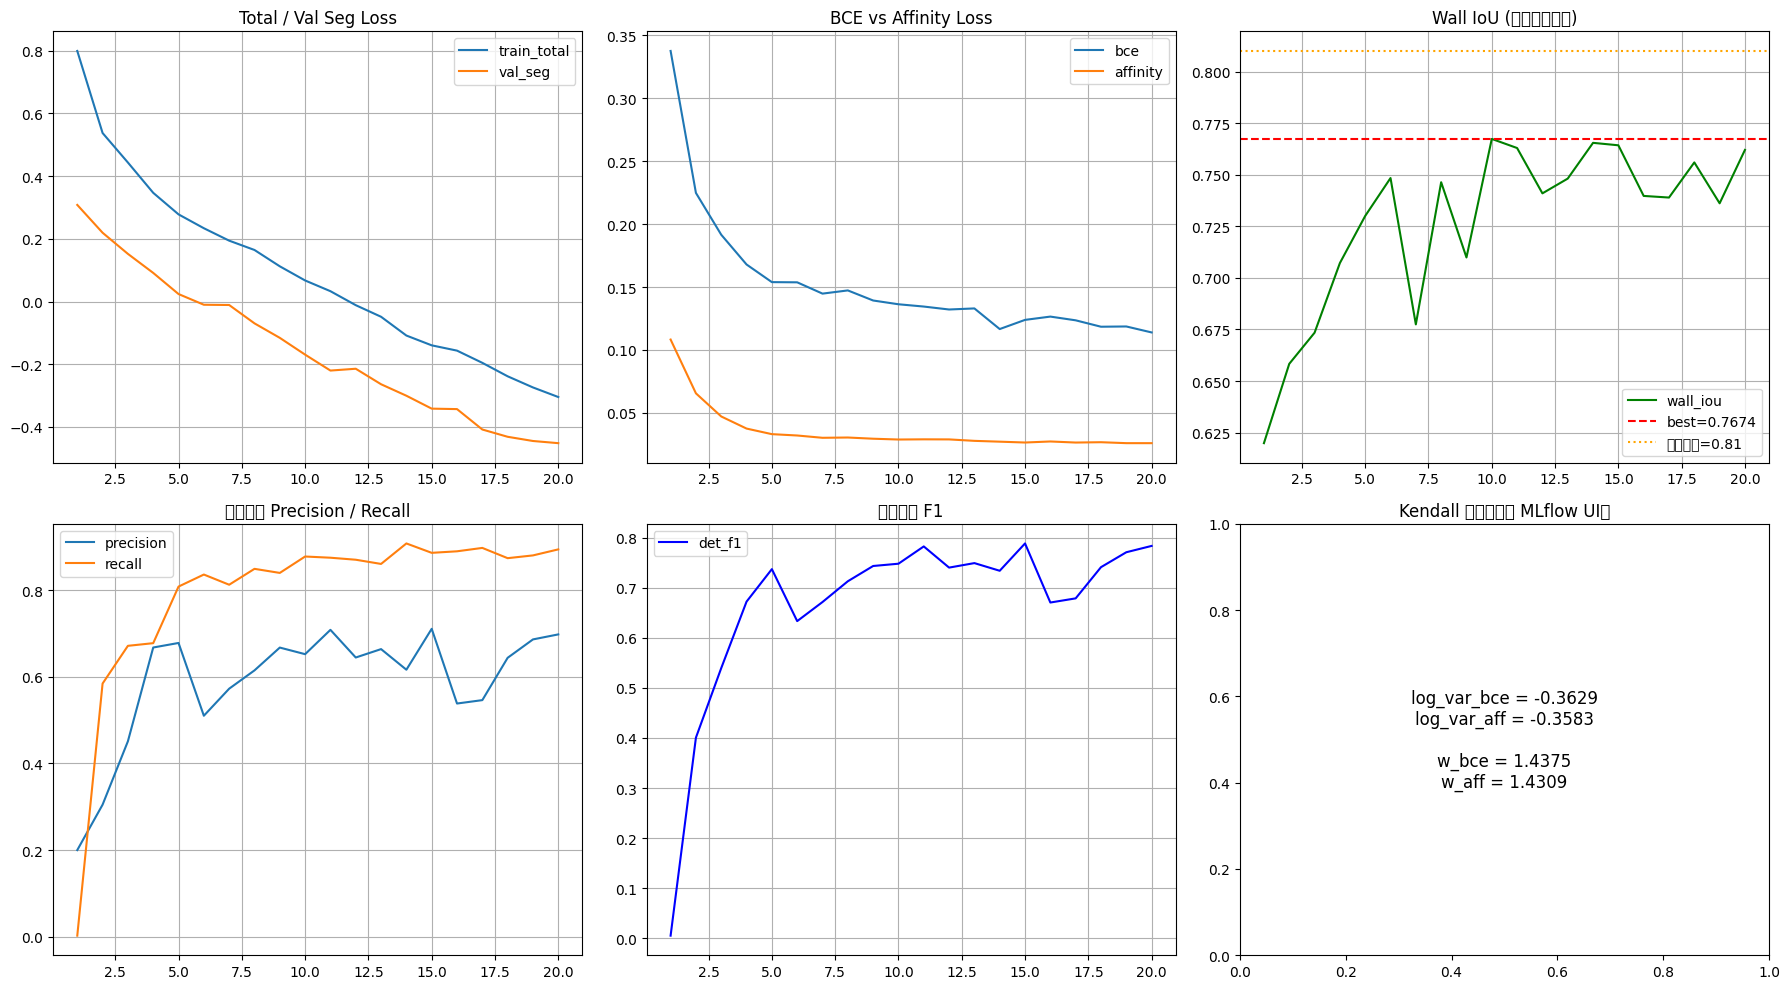

✓ 训练曲线已上传到 MLflow


In [30]:
epochs = range(1, len(history['loss_total']) + 1)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes[0,0].plot(epochs, history['loss_total'], label='train_total')
axes[0,0].plot(epochs, history['val_seg_loss'], label='val_seg')
axes[0,0].set_title('Total / Val Seg Loss'); axes[0,0].legend(); axes[0,0].grid(True)

axes[0,1].plot(epochs, history['loss_bce'], label='bce')
axes[0,1].plot(epochs, history['loss_aff'], label='affinity')
axes[0,1].set_title('BCE vs Affinity Loss'); axes[0,1].legend(); axes[0,1].grid(True)

axes[0,2].plot(epochs, history['val_wall_iou'], color='green', label='wall_iou')
axes[0,2].axhline(y=best_wall_iou, color='red', linestyle='--',
                   label=f'best={best_wall_iou:.4f}')
axes[0,2].axhline(y=0.81, color='orange', linestyle=':',
                   label='论文目标=0.81')
axes[0,2].set_title('Wall IoU (论文主要指标)'); axes[0,2].legend(); axes[0,2].grid(True)

axes[1,0].plot(epochs, history['det_precision'], label='precision')
axes[1,0].plot(epochs, history['det_recall'],    label='recall')
axes[1,0].set_title('门窗检测 Precision / Recall'); axes[1,0].legend(); axes[1,0].grid(True)

axes[1,1].plot(epochs, history['det_f1'], color='blue', label='det_f1')
axes[1,1].set_title('门窗检测 F1'); axes[1,1].legend(); axes[1,1].grid(True)

# Kendall 权重变化（从 MLflow 读取）
axes[1,2].set_title('Kendall 权重（参考 MLflow UI）')
axes[1,2].text(0.5, 0.5, f'log_var_bce = {seg_criterion.kendall.log_var_bce.item():.4f}\n'
               f'log_var_aff = {seg_criterion.kendall.log_var_aff.item():.4f}\n\n'
               f'w_bce = {torch.exp(-seg_criterion.kendall.log_var_bce).item():.4f}\n'
               f'w_aff = {torch.exp(-seg_criterion.kendall.log_var_aff).item():.4f}',
               ha='center', va='center', fontsize=12,
               transform=axes[1,2].transAxes)

plt.tight_layout()
curves_path = f'{CFG.checkpoint_dir}/training_curves.png'
plt.savefig(curves_path, dpi=120)
plt.show()

with mlflow.start_run(run_id=run.info.run_id):
    mlflow.log_artifact(curves_path, artifact_path='plots')
    print('✓ 训练曲线已上传到 MLflow')

## 11. 保存到 GCS + MLflow

In [ ]:
results = {
    'model':          'SharedResNet50_FPN_FasterRCNN',
    'best_wall_iou':  best_wall_iou,
    'paper_target':   0.81,
    'epochs_trained': CFG.max_epochs,
    'training_date':  time.strftime('%Y-%m-%d'),
    'mlflow_run_id':  run.info.run_id,
    'kendall_weights': {
        'log_var_bce': seg_criterion.kendall.log_var_bce.item(),
        'log_var_aff': seg_criterion.kendall.log_var_aff.item(),
        'w_bce': torch.exp(-seg_criterion.kendall.log_var_bce).item(),
        'w_aff': torch.exp(-seg_criterion.kendall.log_var_aff).item(),
    },
}
results_path = f'{CFG.checkpoint_dir}/training_results.json'
with open(results_path, 'w') as f:
    json.dump(results, f, indent=2)

with mlflow.start_run(run_id=run.info.run_id):
    mlflow.log_artifact(f'{CFG.checkpoint_dir}/best_model.pth', 'model')
    mlflow.log_artifact(results_path, 'results')

gcs_path = f'gs://{CFG.gcs_bucket}/{CFG.gcs_model_dir}/'
for src, dst in [
    (f'{CFG.checkpoint_dir}/best_model.pth',    f'{gcs_path}best_model.pth'),
    (results_path,                               f'{gcs_path}training_results.json'),
    (curves_path,                                f'{gcs_path}training_curves.png'),
]:
    ret = subprocess.run(f'gsutil cp {src} {dst}',
                         shell=True, capture_output=True, text=True)
    print(f'{"✓" if ret.returncode==0 else "✗"} {dst.split("/")[-1]}')

print(f'\n最优 wall IoU = {best_wall_iou:.4f}  (论文目标: 0.81)')

## 12. 推理验证

In [ ]:
ckpt = torch.load(f'{CFG.checkpoint_dir}/best_model.pth', map_location=DEVICE)
model.load_state_dict(ckpt['model_state'])
model.eval()
print(f'✓ 最优模型加载  epoch={ckpt["epoch"]}  '
      f'wall_iou={ckpt["val_wall_iou"]:.4f}  '
      f'det_f1={ckpt["det_f1"]:.4f}')

mean_t = torch.tensor(CFG.norm_mean).view(3,1,1)
std_t  = torch.tensor(CFG.norm_std).view(3,1,1)

fig, axes = plt.subplots(3, 4, figsize=(20, 15))

for i in range(3):
    sample  = val_ds[i * 50]
    img_t   = sample['image'].unsqueeze(0).to(DEVICE)
    mask_gt = sample['mask'].numpy()

    with torch.no_grad():
        out       = model(img_t)
        pred_mask = out['seg_logits'].argmax(dim=1)[0].cpu().numpy()
        det_out   = out['det_outputs'][0]

    wall_iou = compute_wall_iou(
        torch.tensor(pred_mask), torch.tensor(mask_gt)
    )
    img_show = (sample['image'] * std_t + mean_t).permute(1,2,0).numpy().clip(0,1)

    # 原图
    axes[i,0].imshow(img_show)
    axes[i,0].set_title(f'输入图像 #{i+1}'); axes[i,0].axis('off')

    # GT 墙体
    axes[i,1].imshow(mask_gt, cmap='gray', vmin=0, vmax=1)
    axes[i,1].set_title('GT 墙体'); axes[i,1].axis('off')

    # 预测墙体
    axes[i,2].imshow(pred_mask, cmap='gray', vmin=0, vmax=1)
    axes[i,2].set_title(f'预测墙体 IoU={wall_iou:.3f}'); axes[i,2].axis('off')

    # 检测结果（门窗 bbox）
    axes[i,3].imshow(img_show)
    boxes  = det_out['boxes'].cpu().numpy()
    scores = det_out['scores'].cpu().numpy()
    labels = det_out['labels'].cpu().numpy()
    for box, score, label in zip(boxes, scores, labels):
        if score < 0.5:
            continue
        x1, y1, x2, y2 = box
        color = 'blue' if label == 1 else 'red'
        rect  = mpatches.Rectangle(
            (x1, y1), x2-x1, y2-y1,
            linewidth=2, edgecolor=color, facecolor='none'
        )
        axes[i,3].add_patch(rect)
        axes[i,3].text(x1, y1-2, f'{"Door" if label==1 else "Window"} {score:.2f}',
                       color=color, fontsize=7)
    axes[i,3].set_title('门(蓝) 窗(红) 检测'); axes[i,3].axis('off')

plt.tight_layout()
inf_path = f'{CFG.checkpoint_dir}/inference_samples.png'
plt.savefig(inf_path, dpi=120)
plt.show()

with mlflow.start_run(run_id=run.info.run_id):
    mlflow.log_artifact(inf_path, 'inference')
    print('✓ 推理结果已上传到 MLflow')